# EV2 - Proyecto de Mineria de Datos

## Analisis de precipitaciones, temperaturas y estaciones meteorologicas en Chile

**Asignatura:** BIY7121 - Mineria de Datos  
**Metodologia:** CRISP-DM  
**Dataset base:** precipitaciones, temperaturas y estaciones meteorologicas de Chile  
**Periodo de analisis:** 2021-2025

Este notebook desarrolla un proyecto de mineria de datos aplicado a informacion meteorologica nacional. El objetivo es analizar el comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas, detectar patrones climaticos relevantes y construir modelos predictivos y descriptivos que apoyen la toma de decisiones.

## Estructura del notebook

La estructura del trabajo sigue las fases solicitadas para el proyecto de Data Mining:

1. **Entendimiento del Negocio**
2. **Entendimiento de Datos**
3. **Transformacion**
4. **Modelamiento**
5. **Evaluacion**
6. **Deploy**

En esta primera entrega se desarrolla completamente la **Fase 1: Entendimiento del Negocio**, dejando preparada la estructura formal para continuar con las siguientes fases.

**Mini objetivo:** cargar librerias, definir rutas de trabajo y verificar que las fuentes de datos existan antes de iniciar el analisis.


In [40]:
from pathlib import Path
import csv
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.plotting import scatter_matrix

try:
    import seaborn as sns
except ImportError:
    sns = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:,.3f}'.format)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

DATA_DIR = Path('.data') / 'DataMining_Datos'

PRECIP_TEMP_CSV = DATA_DIR / 'dataset_precipitaciones_temperaturas_chile.csv'
PRECIP_CSV = DATA_DIR / 'dataset_precipitaciones_diarias_chile_COMPLETO.csv'
STATIONS_JSON = DATA_DIR / 'getEstacionesRedEma.json'
CHILE_GEOJSON = Path('.data') / 'chile_country.geojson'

fuentes = {
    'Dataset precipitaciones + temperaturas': PRECIP_TEMP_CSV,
    'Dataset precipitaciones diarias': PRECIP_CSV,
    'Metadata de estaciones': STATIONS_JSON,
    'GeoJSON Chile': CHILE_GEOJSON,
}

for nombre, ruta in fuentes.items():
    estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
    print(f'{nombre}: {estado} -> {ruta}')


Dataset precipitaciones + temperaturas: OK -> .data\DataMining_Datos\dataset_precipitaciones_temperaturas_chile.csv
Dataset precipitaciones diarias: OK -> .data\DataMining_Datos\dataset_precipitaciones_diarias_chile_COMPLETO.csv
Metadata de estaciones: OK -> .data\DataMining_Datos\getEstacionesRedEma.json
GeoJSON Chile: OK -> .data\chile_country.geojson


# 1. Entendimiento del Negocio

La fase de entendimiento del negocio define el contexto del problema, los datos disponibles, las hipotesis iniciales, los indicadores clave y el problema de mineria de datos que se abordara. Esta fase es fundamental en CRISP-DM, porque orienta las decisiones posteriores de limpieza, transformacion, modelamiento y evaluacion.

## 1.1 Contexto

Chile presenta una geografia extensa y diversa, con diferencias climaticas importantes entre el norte, centro, sur, zonas costeras, valles, precordillera y cordillera. Esta diversidad hace que el comportamiento de las precipitaciones y temperaturas varie de forma significativa segun ubicacion, altura, estacion del anio y zona geografica.

El analisis de datos meteorologicos permite transformar registros historicos en conocimiento util para la toma de decisiones. En particular, la informacion de precipitaciones, temperaturas y estaciones puede apoyar procesos relacionados con monitoreo climatico, gestion territorial, planificacion agricola, prevencion de riesgos, gestion hidrica y deteccion de eventos extremos.

Desde la perspectiva de mineria de datos, el problema no consiste solo en describir registros climaticos, sino en descubrir patrones, relaciones y comportamientos que no son evidentes al observar los datos de forma aislada. Por ello, el proyecto se abordara mediante una combinacion de analisis exploratorio, limpieza de datos, transformacion de variables, modelos predictivos y modelos descriptivos.

## 1.2 Datos relevantes

Los datos disponibles se encuentran en la carpeta `.data` y corresponden a registros meteorologicos asociados a estaciones ubicadas en distintas regiones de Chile.

| Fuente | Ruta | Uso en el proyecto |
|---|---|---|
| Dataset de precipitaciones y temperaturas | `.data/DataMining_Datos/dataset_precipitaciones_temperaturas_chile.csv` | Fuente principal del proyecto. Contiene precipitacion, temperatura, fecha, estacion y variables geograficas. |
| Dataset de precipitaciones diarias | `.data/DataMining_Datos/dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Fuente de respaldo para contrastar registros de precipitacion. |
| Metadata de estaciones | `.data/DataMining_Datos/getEstacionesRedEma.json` | Informacion descriptiva de estaciones meteorologicas: codigo, nombre, region, zona, coordenadas y altura. |
| Mapa de Chile | `.data/chile_country.geojson` | Apoyo opcional para visualizaciones geograficas. |

Resumen verificado del dataset principal:

| Caracteristica | Valor |
|---|---:|
| Registros | 187.876 |
| Periodo | 2021-01-01 a 2025-12-31 |
| Estaciones presentes en el dataset | 109 |
| Estaciones informadas en metadata JSON | 148 |
| Regiones | 16 |
| Zonas geograficas | Cordillera, Litoral, PreCordillera, Secano Costero, Secano Interior, Valle |
| Filas con formato especial a corregir | 74.112 |
| Nulos en `agua_caida` | 9,08% |
| Nulos en `temp_max` | 11,20% |
| Nulos en `temp_min` | 11,69% |
| Nulos en `temp_media` | 12,09% |

Variables principales:

| Grupo | Variables | Descripcion |
|---|---|---|
| Temporales | `fecha`, `anio`, `mes`, `dia` | Permiten analizar estacionalidad y comportamiento por periodo. |
| Geograficas | `region`, `nombre_region`, `latitud`, `longitud`, `altura`, `zona_geografica` | Permiten relacionar el clima con ubicacion y caracteristicas territoriales. |
| Estacion | `codigo_estacion`, `nombre_estacion` | Identifican el origen de cada registro meteorologico. |
| Precipitacion | `agua_caida` | Variable numerica principal para analizar lluvia diaria. |
| Temperatura | `temp_max`, `temp_min`, `temp_media` | Variables numericas para analizar comportamiento termico. |

Una consideracion importante es que el dataset principal presenta filas completas encerradas entre comillas, lo que requiere una carga controlada del archivo antes de iniciar el analisis. Este hallazgo sera tratado formalmente en la fase de entendimiento y limpieza de datos.

**Mini objetivo:** resumir las caracteristicas principales del dataset para dejar evidencia rapida de la fuente de datos usada en el proyecto.


In [41]:
resumen_datos = pd.DataFrame([
    {'Elemento': 'Registros del dataset principal', 'Valor': '187.876'},
    {'Elemento': 'Periodo de analisis', 'Valor': '2021-01-01 a 2025-12-31'},
    {'Elemento': 'Estaciones presentes en dataset', 'Valor': '109'},
    {'Elemento': 'Estaciones en metadata JSON', 'Valor': '148'},
    {'Elemento': 'Regiones', 'Valor': '16'},
    {'Elemento': 'Variables climaticas principales', 'Valor': 'agua_caida, temp_max, temp_min, temp_media'},
    {'Elemento': 'Variables geograficas principales', 'Valor': 'region, zona_geografica, latitud, longitud, altura'},
    {'Elemento': 'Problema de formato detectado', 'Valor': '74.112 filas completas entre comillas'},
])

resumen_datos

,Elemento,Valor
0,Registros del dataset principal,187.876
1,Periodo de analisis,2021-01-01 a 2025-12-31
2,Estaciones presentes en dataset,109
3,Estaciones en metadata JSON,148
4,Regiones,16
5,Variables climaticas principales,"agua_caida, temp_max, temp_min, temp_media"
6,Variables geograficas principales,"region, zona_geografica, latitud, longitud, al..."
7,Problema de formato detectado,74.112 filas completas entre comillas


## 1.3 Hipotesis y tesis consideradas

### Tesis general del proyecto

El comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas en Chile puede explicarse parcialmente mediante variables temporales, geograficas y termicas. A partir de estas variables es posible detectar patrones climaticos, identificar eventos extremos y construir modelos predictivos y descriptivos utiles para la toma de decisiones.

### Hipotesis de trabajo

| Hipotesis | Descripcion | Variables asociadas | Tipo de analisis esperado |
|---|---|---|---|
| H1 | La precipitacion diaria presenta diferencias significativas entre regiones y zonas geograficas. | `agua_caida`, `region`, `zona_geografica` | Analisis estadistico, visualizacion y comparacion por grupos. |
| H2 | La probabilidad de lluvia varia segun el mes y la estacion del anio. | `agua_caida`, `mes`, `fecha` | Creacion de variables temporales y clasificacion de dias lluviosos. |
| H3 | La temperatura media se relaciona con la latitud, altura y zona geografica de la estacion. | `temp_media`, `latitud`, `altura`, `zona_geografica` | Correlacion, regresion y visualizacion geografica. |
| H4 | Los dias con lluvia intensa presentan patrones distintos de temperatura y ubicacion respecto de dias sin lluvia. | `agua_caida`, `temp_media`, `temp_max`, `temp_min`, `region`, `zona_geografica` | Clasificacion y analisis comparativo. |
| H5 | Es posible agrupar estaciones meteorologicas con comportamientos climaticos similares. | `agua_caida`, `temp_media`, `altura`, `latitud`, `longitud` | Clustering con K-Means. |
| H6 | Algunos valores extremos de precipitacion pueden corresponder a eventos climaticos excepcionales o a posibles problemas de calidad de datos. | `agua_caida`, `fecha`, `codigo_estacion`, `nombre_estacion` | Deteccion de outliers y revision contextual. |

Estas hipotesis guiaran la seleccion de variables, la construccion de nuevas caracteristicas y la eleccion de modelos en las siguientes fases del proyecto.

## 1.4 KPI's relevantes

Los KPI propuestos permiten evaluar el comportamiento climatico, la calidad de los datos y el rendimiento posterior de los modelos.

| KPI | Formula o criterio | Utilidad |
|---|---|---|
| Precipitacion acumulada | Suma de `agua_caida` por estacion, region, zona o periodo | Identificar territorios con mayor volumen de lluvia. |
| Precipitacion promedio diaria | Promedio de `agua_caida` | Comparar comportamiento normal entre estaciones o regiones. |
| Dias con lluvia | Conteo de registros donde `agua_caida > 0` | Medir frecuencia de lluvia. |
| Porcentaje de dias con lluvia | Dias con lluvia / total de dias observados | Comparar estaciones con distinta cantidad de registros. |
| Eventos de lluvia intensa | Registros sobre un umbral, por ejemplo percentil 95 de `agua_caida` | Detectar eventos relevantes para riesgo climatico. |
| Temperatura media promedio | Promedio de `temp_media` | Caracterizar comportamiento termico por zona. |
| Rango termico promedio | Promedio de `temp_max - temp_min` | Medir variabilidad diaria de temperatura. |
| Cobertura de datos por estacion | Registros validos / registros esperados | Evaluar calidad y completitud de informacion. |
| Porcentaje de nulos por variable | Nulos / total de registros | Priorizar tratamiento de datos faltantes. |
| RMSE / R2 | Metricas de regresion | Evaluar modelos que predigan valores numericos. |
| Accuracy / F1-score / matriz de confusion | Metricas de clasificacion | Evaluar modelos que predigan lluvia o lluvia intensa. |
| Silhouette score | Metrica de clustering | Evaluar separacion y coherencia de grupos. |

Los KPI climaticos se usaran en el analisis exploratorio, mientras que los KPI de rendimiento se usaran en la fase de evaluacion de modelos.

**Mini objetivo:** organizar los KPI propuestos en una tabla simple para conectar el problema de negocio con indicadores medibles.


In [42]:
kpis = pd.DataFrame([
    {'KPI': 'Precipitacion acumulada', 'Variable base': 'agua_caida', 'Nivel': 'region / zona / estacion / periodo'},
    {'KPI': 'Precipitacion promedio diaria', 'Variable base': 'agua_caida', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Dias con lluvia', 'Variable base': 'agua_caida > 0', 'Nivel': 'estacion / region / mes'},
    {'KPI': 'Eventos de lluvia intensa', 'Variable base': 'agua_caida sobre umbral', 'Nivel': 'estacion / region / fecha'},
    {'KPI': 'Temperatura media promedio', 'Variable base': 'temp_media', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Rango termico promedio', 'Variable base': 'temp_max - temp_min', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Porcentaje de nulos', 'Variable base': 'isna()', 'Nivel': 'variable / estacion'},
])

kpis

,KPI,Variable base,Nivel
0,Precipitacion acumulada,agua_caida,region / zona / estacion / periodo
1,Precipitacion promedio diaria,agua_caida,region / zona / estacion
2,Dias con lluvia,agua_caida > 0,estacion / region / mes
3,Eventos de lluvia intensa,agua_caida sobre umbral,estacion / region / fecha
4,Temperatura media promedio,temp_media,region / zona / estacion
5,Rango termico promedio,temp_max - temp_min,region / zona / estacion
6,Porcentaje de nulos,isna(),variable / estacion


## 1.5 Problema de negocio (Prediccion)

El problema de negocio se define como la necesidad de anticipar y comprender el comportamiento de precipitaciones y temperaturas en estaciones meteorologicas de Chile, utilizando informacion historica, geografica y temporal.

Desde la perspectiva de mineria de datos, el proyecto abordara tres lineas de modelamiento:

### Problema predictivo de regresion

Predecir una variable numerica climatica a partir de caracteristicas temporales, geograficas y termicas.

**Variable objetivo candidata:**

- `agua_caida`: precipitacion diaria registrada.
- `temp_media`: temperatura media diaria.

**Variables explicativas candidatas:**

- `mes`, `anio`, `dia`
- `region`, `zona_geografica`
- `latitud`, `longitud`, `altura`
- `temp_max`, `temp_min`, `temp_media`, segun la variable objetivo seleccionada

### Problema predictivo de clasificacion

Clasificar si un registro corresponde a un dia sin lluvia, con lluvia o con lluvia intensa.

**Variables objetivo candidatas:**

- `llueve`: variable binaria creada a partir de `agua_caida > 0`.
- `lluvia_intensa`: variable binaria creada a partir de un umbral estadistico, por ejemplo el percentil 95 de `agua_caida`.

### Problema descriptivo de clustering

Agrupar estaciones o registros climaticos con comportamientos similares, usando variables como precipitacion promedio, temperatura media, altura, latitud, longitud y zona geografica.

### Criterios de exito

El proyecto sera considerado exitoso si logra:

1. Identificar patrones climaticos interpretables por region, zona geografica, estacion y mes.
2. Detectar y justificar el tratamiento de nulos y outliers.
3. Construir variables nuevas utiles para el modelamiento.
4. Comparar modelos de regresion, clasificacion y clustering.
5. Evaluar los modelos con metricas coherentes: RMSE, R2, matriz de confusion, F1-score y Silhouette score.
6. Traducir resultados tecnicos en conclusiones comprensibles para la toma de decisiones.

Con esta definicion, las siguientes fases se orientaran a preparar un dataset confiable, explorar patrones y construir modelos que respondan directamente a las hipotesis planteadas.

## Cierre de Fase 1

La Fase 1 establece el marco formal del proyecto. Se definio el contexto, se rectificaron las fuentes de datos disponibles, se formularon hipotesis, se establecieron KPI relevantes y se delimito el problema de negocio como un proyecto mixto de prediccion y descripcion climatica.

La siguiente fase corresponde al **Entendimiento de Datos**, donde se cargara el dataset, se corregira el formato especial de algunas filas, se identificaran tipos de variables, nulos, outliers, estadisticos basicos, correlaciones y primeros patrones observados.

# 2. Entendimiento Datos

En esta fase se estudia la estructura real del dataset antes de tomar decisiones de limpieza profunda o modelamiento. El objetivo es conocer la calidad de los datos, identificar tipos de variables, nulos, outliers, distribuciones, correlaciones y primeros patrones climaticos.

La decision principal de esta fase es trabajar con el archivo `dataset_precipitaciones_temperaturas_chile.csv`, porque integra precipitaciones, temperaturas, estaciones y variables geograficas. El archivo de precipitaciones diarias se usara como respaldo si se requiere contrastar la variable `agua_caida`.


## 2.0 Carga controlada del dataset principal

Antes de analizar los datos se debe resolver un problema de formato detectado en el CSV principal: una parte de las filas viene encerrada completamente entre comillas. Si se carga el archivo directamente, esas filas quedan interpretadas como un solo campo y se distorsionan los tipos de datos, los nulos y los conteos de estaciones.

Por esta razon se construye una carga controlada. Esta carga no cambia los valores originales del dataset; solo corrige la lectura de filas completas entre comillas para que cada columna quede en su posicion correcta.


**Mini objetivo:** definir explicitamente las columnas esperadas del archivo principal para controlar que la carga del CSV quede alineada.


In [43]:
COLUMNAS_CLIMA = [
    'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
    'anio', 'mes', 'dia', 'agua_caida', 'fecha', 'nombre_estacion',
    'nombre_region', 'zona_geografica', 'temp_max', 'temp_min', 'temp_media'
]


**Mini objetivo:** crear una funcion de carga robusta que corrija filas completas entre comillas y convierta los tipos de datos principales.


In [44]:
def cargar_dataset_clima(ruta_csv):
    filas = []
    filas_entre_comillas = 0
    filas_con_error = []

    with open(ruta_csv, 'r', encoding='utf-8-sig', newline='') as archivo:
        _ = next(archivo)

        for numero_linea, fila_original in enumerate(archivo, start=2):
            fila = fila_original.rstrip('\n\r')

            if len(fila) >= 2 and fila[0] == '"' and fila[-1] == '"':
                filas_entre_comillas += 1
                fila = fila[1:-1].replace('""', '"')

            valores = next(csv.reader([fila]))

            if len(valores) == len(COLUMNAS_CLIMA):
                filas.append(valores)
            else:
                filas_con_error.append((numero_linea, len(valores)))

    datos = pd.DataFrame(filas, columns=COLUMNAS_CLIMA)

    columnas_numericas = [
        'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
        'anio', 'mes', 'dia', 'agua_caida', 'temp_max', 'temp_min', 'temp_media'
    ]
    for columna in columnas_numericas:
        datos[columna] = pd.to_numeric(datos[columna], errors='coerce')

    datos['fecha'] = pd.to_datetime(datos['fecha'], errors='coerce')

    def corregir_texto_mojibake(valor):
        if pd.isna(valor):
            return valor
        valor = str(valor)
        try:
            return valor.encode('latin1').decode('utf-8')
        except UnicodeError:
            return valor

    for columna in ['nombre_estacion', 'nombre_region', 'zona_geografica']:
        datos[columna] = datos[columna].apply(corregir_texto_mojibake).astype('string').str.strip()

    resumen = {
        'filas_cargadas': len(datos),
        'columnas_cargadas': datos.shape[1],
        'filas_entre_comillas_corregidas': filas_entre_comillas,
        'filas_con_error': len(filas_con_error),
    }

    return datos, resumen, filas_con_error


**Mini objetivo:** ejecutar la carga controlada y revisar una muestra inicial del dataset corregido.


In [45]:
df, resumen_carga, filas_con_error = cargar_dataset_clima(PRECIP_TEMP_CSV)

resumen_carga_df = pd.DataFrame([resumen_carga])
display(resumen_carga_df)
display(df.head())


,filas_cargadas,columnas_cargadas,filas_entre_comillas_corregidas,filas_con_error
0,187876,16,74112,0


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,temp_max,temp_min,temp_media
0,170001,15,4084,-17.595,-69.478,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
1,170001,15,4084,-17.595,-69.478,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
2,170001,15,4084,-17.595,-69.478,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
3,170001,15,4084,-17.595,-69.478,2023,1,4,NaN,2023-01-04,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
4,170001,15,4084,-17.595,-69.478,2023,1,5,NaN,2023-01-05,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN


**Analisis de carga:**

La carga controlada permite trabajar con el dataset principal sin perder columnas ni registros. El punto mas importante es que las filas completas entre comillas no se eliminan: se corrige su lectura para conservar la informacion disponible. Esto es coherente con buenas practicas de preparacion de datos, porque primero se corrige el problema de estructura antes de evaluar nulos, outliers o patrones.


## 2.1 Identificar Tipos de variables/atributos

En mineria de datos es necesario distinguir entre variables numericas, categoricas, temporales e identificadores. Esta clasificacion define que analisis se puede hacer y que transformaciones seran necesarias antes del modelamiento.


**Mini objetivo:** clasificar las variables segun su naturaleza: identificadores, temporales, categoricas, geograficas y climaticas.


In [46]:
tipos_variables = pd.DataFrame([
    {'variable': 'codigo_estacion', 'tipo_conceptual': 'Identificador', 'uso': 'Identifica la estacion meteorologica'},
    {'variable': 'region', 'tipo_conceptual': 'Categorica codificada', 'uso': 'Agrupacion territorial'},
    {'variable': 'nombre_region', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Etiqueta de region'},
    {'variable': 'zona_geografica', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Zona fisica o climatica'},
    {'variable': 'nombre_estacion', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Nombre de estacion'},
    {'variable': 'fecha', 'tipo_conceptual': 'Temporal', 'uso': 'Analisis por dia, mes, anio y estacion'},
    {'variable': 'anio, mes, dia', 'tipo_conceptual': 'Temporales numericas', 'uso': 'Componentes de fecha'},
    {'variable': 'altura, latitud, longitud', 'tipo_conceptual': 'Numericas geograficas', 'uso': 'Ubicacion y condicion territorial'},
    {'variable': 'agua_caida', 'tipo_conceptual': 'Numerica continua', 'uso': 'Precipitacion diaria'},
    {'variable': 'temp_max, temp_min, temp_media', 'tipo_conceptual': 'Numericas continuas', 'uso': 'Temperatura diaria'},
])

display(tipos_variables)
display(df.dtypes.to_frame('tipo_python'))


,variable,tipo_conceptual,uso
0,codigo_estacion,Identificador,Identifica la estacion meteorologica
1,region,Categorica codificada,Agrupacion territorial
2,nombre_region,Categorica nominal,Etiqueta de region
3,zona_geografica,Categorica nominal,Zona fisica o climatica
4,nombre_estacion,Categorica nominal,Nombre de estacion
5,fecha,Temporal,"Analisis por dia, mes, anio y estacion"
6,"anio, mes, dia",Temporales numericas,Componentes de fecha
7,"altura, latitud, longitud",Numericas geograficas,Ubicacion y condicion territorial
8,agua_caida,Numerica continua,Precipitacion diaria
9,"temp_max, temp_min, temp_media",Numericas continuas,Temperatura diaria


,tipo_python
codigo_estacion,int64
region,int64
altura,int64
latitud,float64
longitud,float64
anio,int64
mes,int64
dia,int64
agua_caida,float64
fecha,datetime64[ns]


**Analisis de tipos:**

El dataset combina variables climaticas, geograficas, temporales y categoricas. Para analisis estadistico y modelamiento, las variables numericas pueden usarse directamente despues de tratar nulos y outliers. Las variables categoricas como `nombre_region` y `zona_geografica` requeriran encoding en fases posteriores. La variable `codigo_estacion` identifica observaciones, pero no debe interpretarse como magnitud numerica.


### Cobertura temporal y territorial

Antes de analizar nulos o modelos, se revisa si los datos cubren adecuadamente el periodo y las regiones disponibles. Esta revision permite detectar concentraciones o vacios importantes en la captura de datos.


**Mini objetivo:** calcular un resumen general para validar cobertura temporal, territorial, duplicados y cantidad de estaciones.


In [47]:
resumen_general = pd.DataFrame([
    {'indicador': 'registros', 'valor': len(df)},
    {'indicador': 'columnas', 'valor': df.shape[1]},
    {'indicador': 'fecha_minima', 'valor': df['fecha'].min()},
    {'indicador': 'fecha_maxima', 'valor': df['fecha'].max()},
    {'indicador': 'estaciones', 'valor': df['codigo_estacion'].nunique()},
    {'indicador': 'regiones', 'valor': df['region'].nunique()},
    {'indicador': 'zonas_geograficas', 'valor': df['zona_geografica'].nunique()},
    {'indicador': 'duplicados', 'valor': df.duplicated().sum()},
])

display(resumen_general)


,indicador,valor
0,registros,187876
1,columnas,16
2,fecha_minima,2021-01-01 00:00:00
3,fecha_maxima,2025-12-31 00:00:00
4,estaciones,109
5,regiones,16
6,zonas_geograficas,6
7,duplicados,0


**Mini objetivo:** visualizar la cobertura de registros por anio y por region para detectar desbalances de datos.


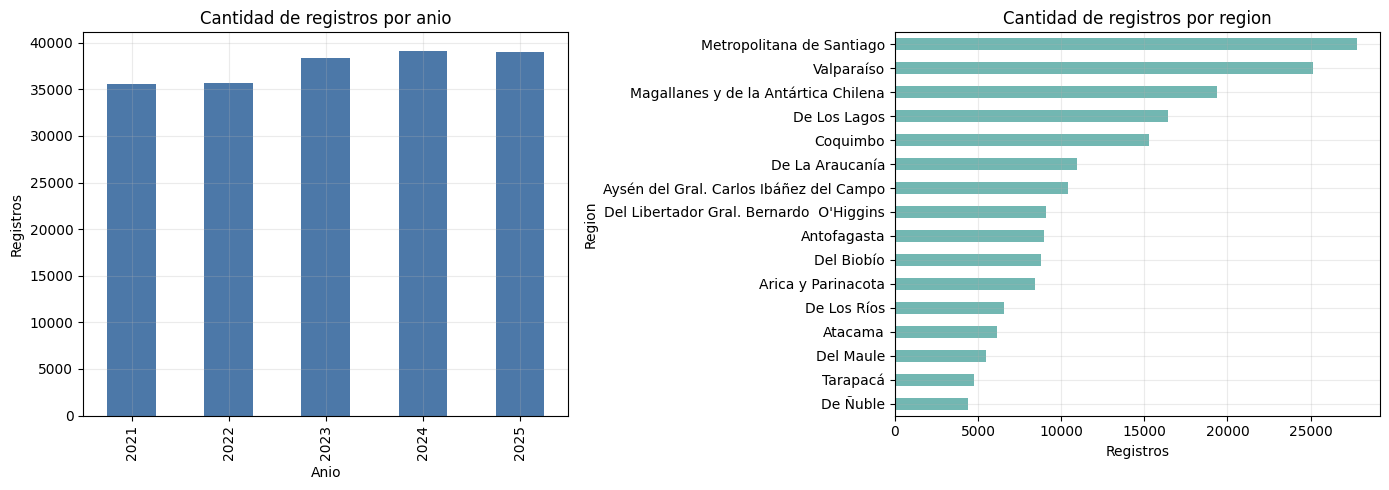

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['anio'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cantidad de registros por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Registros')

registros_region = df.groupby('nombre_region')['codigo_estacion'].size().sort_values()
registros_region.plot(kind='barh', ax=axes[1], color='#72b7b2')
axes[1].set_title('Cantidad de registros por region')
axes[1].set_xlabel('Registros')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis de cobertura:**

El dataset cubre varios anios y todas las regiones del pais, lo que permite comparar comportamientos territoriales y temporales. Sin embargo, la cantidad de registros no es igual para todas las regiones ni estaciones, por lo que en analisis posteriores conviene usar promedios, porcentajes o tasas cuando se comparen territorios con distinta cantidad de observaciones.


## 2.2 Identificar Nulo

La busqueda de valores nulos es un requisito central de la preparacion de datos. En este proyecto los nulos son especialmente importantes porque pueden representar ausencia de medicion, fallas de estacion o dias sin informacion disponible. No se asumira automaticamente que un nulo en precipitacion equivale a cero.


**Mini objetivo:** cuantificar valores nulos por variable para priorizar el tratamiento de datos faltantes.


In [49]:
nulos = df.isna().sum().to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(2)
nulos = nulos.sort_values('porcentaje', ascending=False)

display(nulos)


,nulos,porcentaje
temp_media,22713,12.090
temp_min,21965,11.690
temp_max,21047,11.200
agua_caida,17063,9.080
codigo_estacion,0,0.000
region,0,0.000
altura,0,0.000
latitud,0,0.000
dia,0,0.000
mes,0,0.000


**Mini objetivo:** graficar el porcentaje de nulos para identificar rapidamente las variables con mayor ausencia de datos.


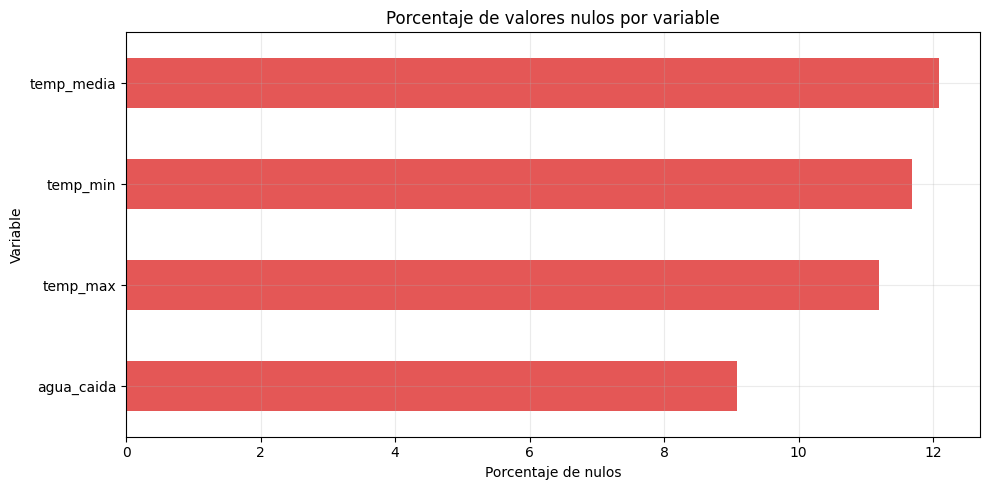

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
nulos[nulos['porcentaje'] > 0]['porcentaje'].sort_values().plot(kind='barh', ax=ax, color='#e45756')
ax.set_title('Porcentaje de valores nulos por variable')
ax.set_xlabel('Porcentaje de nulos')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()


**Mini objetivo:** revisar el porcentaje de nulos climaticos por anio usando un heatmap legible con etiquetas de datos.


anio,2021,2022,2023,2024,2025
agua_caida,11.840,9.550,12.520,7.540,4.310
temp_max,14.950,13.110,14.360,8.980,5.170
temp_min,16.010,14.280,14.950,8.810,5.080
temp_media,16.560,15.050,15.300,9.000,5.260


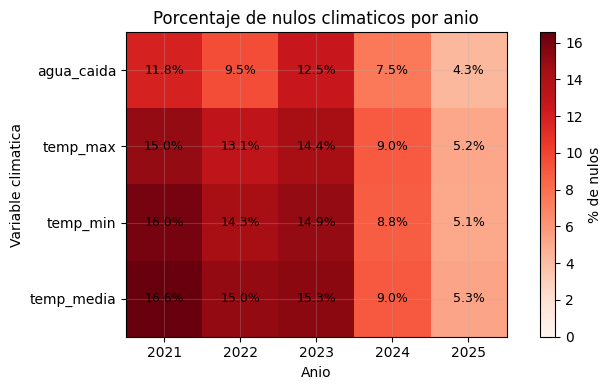

In [51]:
columnas_revision_nulos = ['agua_caida', 'temp_max', 'temp_min', 'temp_media']

nulos_climaticos_anio = df.groupby('anio')[columnas_revision_nulos].apply(
    lambda datos: datos.isna().mean() * 100
).T
nulos_climaticos_anio.columns = nulos_climaticos_anio.columns.astype(int)

display(nulos_climaticos_anio.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(nulos_climaticos_anio, cmap='Reds', vmin=0)

ax.set_title('Porcentaje de nulos climaticos por anio')
ax.set_xlabel('Anio')
ax.set_ylabel('Variable climatica')
ax.set_xticks(range(len(nulos_climaticos_anio.columns)))
ax.set_xticklabels(nulos_climaticos_anio.columns)
ax.set_yticks(range(len(nulos_climaticos_anio.index)))
ax.set_yticklabels(nulos_climaticos_anio.index)

for fila in range(len(nulos_climaticos_anio.index)):
    for columna in range(len(nulos_climaticos_anio.columns)):
        valor = nulos_climaticos_anio.iloc[fila, columna]
        color_texto = 'white' if valor >= 20 else 'black'
        ax.text(columna, fila, f'{valor:.1f}%', ha='center', va='center', color=color_texto, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% de nulos')
plt.tight_layout()
plt.show()


**Analisis de nulos:**

Los nulos se concentran principalmente en variables climaticas: `agua_caida`, `temp_max`, `temp_min` y `temp_media`. El heatmap por anio permite revisar si la ausencia de datos se concentra en periodos especificos o si se mantiene relativamente estable. Esto confirma que el tratamiento de nulos debe ser diferenciado por variable. Para la fase de entendimiento se mantienen los nulos visibles; para modelamiento se evaluara imputacion o eliminacion controlada segun el objetivo del modelo.


## 2.3 Identificar Outliers

Los outliers se revisan con estadisticos, percentiles y boxplots. En datos meteorologicos, un valor extremo puede ser un evento real o un error de medicion. Por eso, en esta fase no se eliminan automaticamente: primero se detectan, se contextualizan y se dejan marcados para decidir su tratamiento en fases posteriores.


**Mini objetivo:** aplicar el metodo IQR para detectar posibles outliers en variables climaticas y geograficas relevantes.


In [52]:
variables_outliers = ['agua_caida', 'temp_max', 'temp_min', 'temp_media', 'altura']
resumen_outliers = []

for columna in variables_outliers:
    serie = df[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

    resumen_outliers.append({
        'variable': columna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'outliers_iqr': outliers,
        'porcentaje_outliers': round(outliers / len(serie) * 100, 2)
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
display(resumen_outliers)


,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
0,agua_caida,0.000,0.100,0.100,-0.150,0.250,32994,19.320
1,temp_max,14.000,24.100,10.100,-1.150,39.250,740,0.440
2,temp_min,4.100,11.400,7.300,-6.850,22.350,1370,0.830
3,temp_media,9.200,16.700,7.500,-2.050,27.950,1373,0.830
4,altura,53.000,474.000,421.000,-578.500,"1,105.500",15523,8.260


**Mini objetivo:** visualizar de forma general que variables presentan mayor cantidad y porcentaje de outliers segun el criterio IQR.


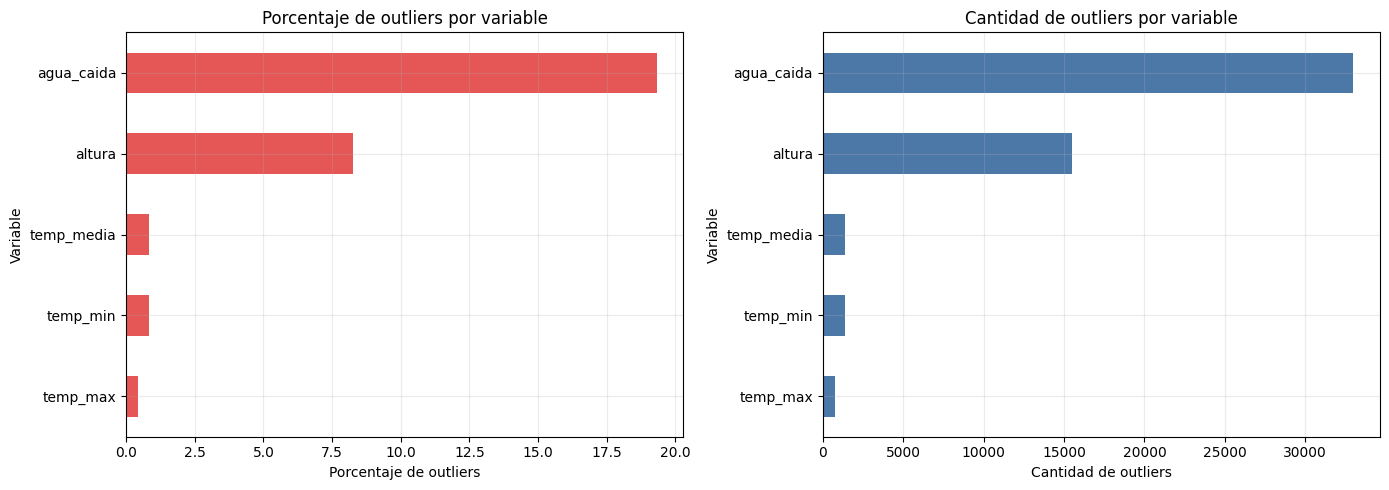

In [53]:
resumen_outliers_ordenado = resumen_outliers.sort_values('porcentaje_outliers')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='porcentaje_outliers',
    ax=axes[0], color='#e45756', legend=False
)
axes[0].set_title('Porcentaje de outliers por variable')
axes[0].set_xlabel('Porcentaje de outliers')
axes[0].set_ylabel('Variable')

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='outliers_iqr',
    ax=axes[1], color='#4c78a8', legend=False
)
axes[1].set_title('Cantidad de outliers por variable')
axes[1].set_xlabel('Cantidad de outliers')
axes[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()


**Mini objetivo:** construir un boxplot individual para cada variable revisada, permitiendo observar dispersion y valores extremos de manera separada.


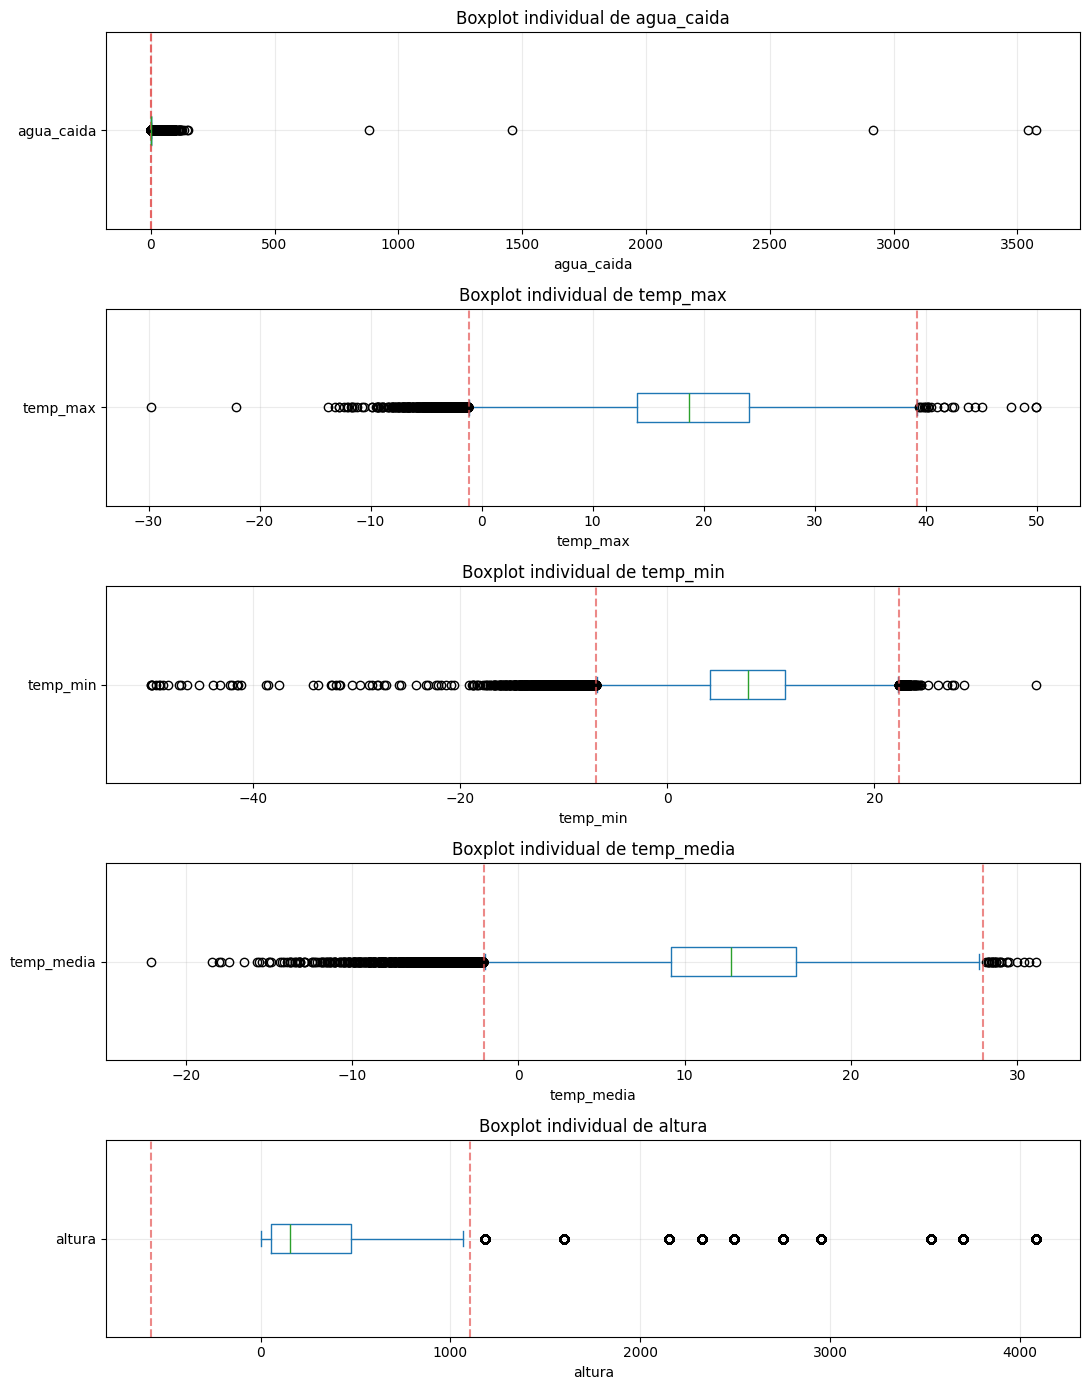

In [54]:
fig, axes = plt.subplots(len(variables_outliers), 1, figsize=(11, 14))

for ax, columna in zip(axes, variables_outliers):
    df[columna].dropna().plot(kind='box', vert=False, ax=ax)
    limites = resumen_outliers.set_index('variable').loc[columna]
    ax.axvline(limites['limite_inferior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.axvline(limites['limite_superior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.set_title(f'Boxplot individual de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis grafico de outliers:**

El grafico general permite comparar rapidamente que variables concentran mas outliers bajo el criterio IQR. Los boxplots individuales complementan esa lectura, porque muestran la forma de la distribucion y la distancia de los valores extremos respecto del rango central. En particular, `agua_caida` requiere cautela: el metodo IQR detecta muchos valores porque la serie tiene muchos ceros y una cola derecha larga. Por eso, para tratamiento se usara un criterio mas conservador basado en extremos altos, no todos los puntos IQR.


**Mini objetivo:** comparar la precipitacion original y transformada con `log1p` para visualizar mejor la asimetria y los valores extremos.


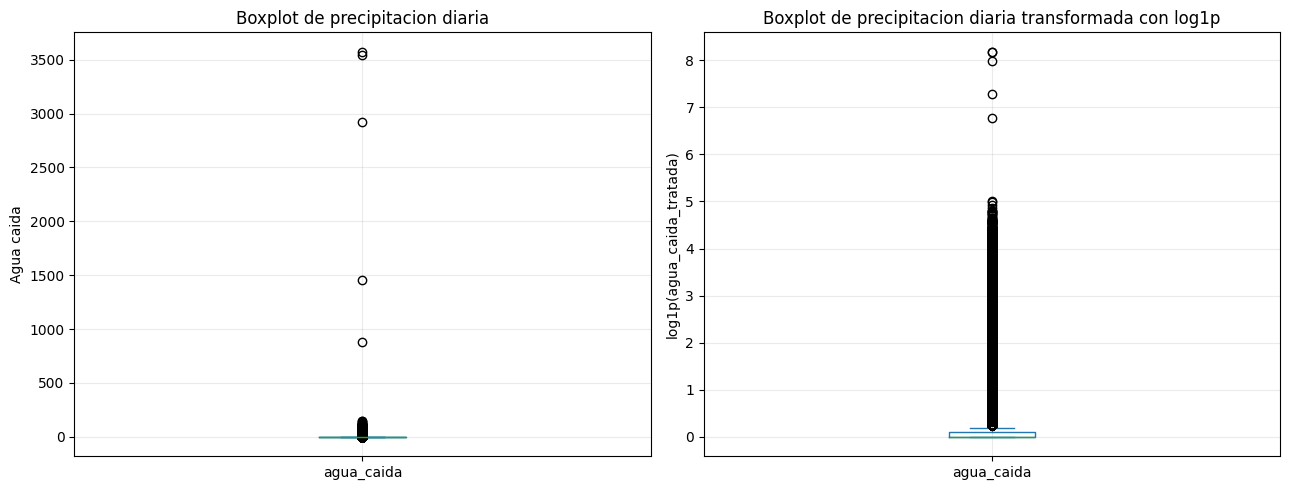

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['agua_caida'].dropna().plot(kind='box', ax=axes[0])
axes[0].set_title('Boxplot de precipitacion diaria')
axes[0].set_ylabel('Agua caida')

np.log1p(df['agua_caida'].dropna()).plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot de precipitacion diaria transformada con log1p')
axes[1].set_ylabel('log1p(agua_caida_tratada)')

plt.tight_layout()
plt.show()


**Mini objetivo:** revisar outliers y dispersion en temperaturas mediante boxplots.


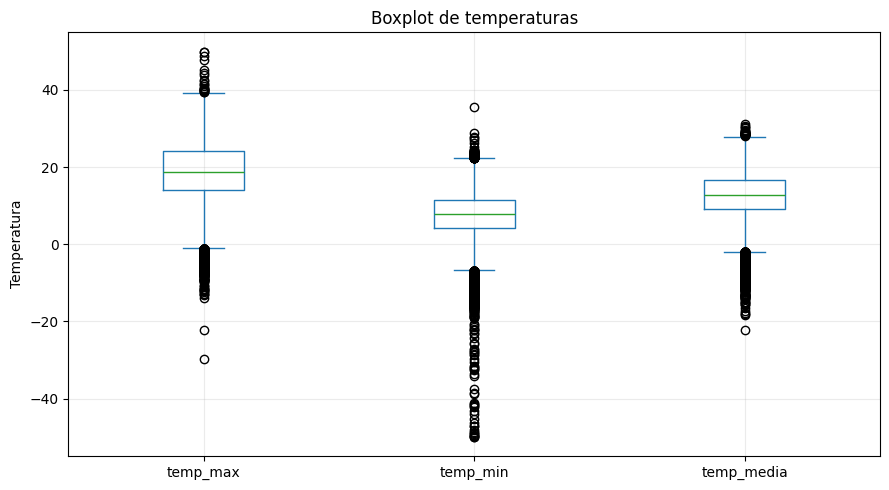

In [56]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['temp_max', 'temp_min', 'temp_media']].plot(kind='box', ax=ax)
ax.set_title('Boxplot de temperaturas')
ax.set_ylabel('Temperatura')
plt.tight_layout()
plt.show()


**Mini objetivo:** listar los mayores registros de precipitacion para contextualizar eventos extremos antes de decidir su tratamiento.


In [57]:
top_precipitaciones = df.sort_values('agua_caida', ascending=False).head(10)[[
    'fecha', 'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'agua_caida', 'temp_media', 'altura'
]]

display(top_precipitaciones)


,fecha,codigo_estacion,nombre_estacion,nombre_region,zona_geografica,agua_caida,temp_media,altura
75680,2025-12-08,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,"3,574.300",21.400,876
133239,2025-12-07,380082,Isla Mocha Ad.,Del Biobío,Litoral,"3,541.500",16.500,6
75679,2025-12-07,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,"2,917.400",19.000,876
133240,2025-12-09,380082,Isla Mocha Ad.,Del Biobío,Litoral,"1,459.900",16.400,6
75681,2025-12-09,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,880.100,21.300,876
97400,2023-08-21,340031,"General Freire, Curicó Ad.",Del Maule,Valle,150.200,13.400,229
74780,2023-06-22,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,145.200,11.000,876
123155,2022-04-28,380018,Lonquimay,De La Araucanía,PreCordillera,136.400,NaN,912
138886,2021-05-31,390043,Corral ESSAL,De Los Ríos,Litoral,126.800,13.900,24
102878,2023-08-21,340066,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,121.300,NaN,81


**Analisis de outliers:**

La variable `agua_caida` es altamente asimetrica: muchos dias tienen precipitacion cero o baja, mientras que pocos registros concentran valores muy altos. Por eso se revisa tambien `log1p(agua_caida)`, que permite observar mejor la distribucion sin eliminar eventos extremos. Los valores mas altos deben ser tratados con especial cuidado, ya que pueden representar eventos climaticos excepcionales o posibles errores de registro.


## 2.4 Transformaciones

En esta fase se realizan transformaciones iniciales orientadas al entendimiento de datos. No se aplicara aun escalamiento ni preparacion definitiva para modelos, porque eso corresponde a la Fase 3. Aqui se verifica la limpieza inicial de textos, se preparan codificaciones simples para analisis y se definen criterios de tratamiento para nulos y outliers.


### 2.4.1 A numericos (Encoder)

Las variables categoricas no pueden ser usadas directamente en muchos modelos matematicos. Como primer paso, se crean codigos numericos para region, zona geografica y macrozona. La macrozona se construye agrupando regiones de Chile en grandes areas climaticas y territoriales: Norte Grande, Norte Chico, Zona Central, Zona Sur y Zona Austral. Esta variable permite comparar patrones de forma mas clara que usando solo regiones individuales.


**Mini objetivo:** crear una copia de trabajo, agregar macrozonas y codificar variables categoricas para analisis exploratorio sin alterar el dataset base.


In [58]:
df_eda = df.copy()

def asignar_macrozona(region):
    if region in [15, 1, 2]:
        return 'Norte Grande'
    if region in [3, 4]:
        return 'Norte Chico'
    if region in [5, 13, 6, 7, 16, 8]:
        return 'Zona Central'
    if region in [9, 14, 10]:
        return 'Zona Sur'
    if region in [11, 12]:
        return 'Zona Austral'
    return 'Sin clasificar'

macrozonas_orden = ['Norte Grande', 'Norte Chico', 'Zona Central', 'Zona Sur', 'Zona Austral']

df_eda['macrozona'] = df_eda['region'].apply(asignar_macrozona)
df_eda['macrozona'] = pd.Categorical(df_eda['macrozona'], categories=macrozonas_orden, ordered=True)

df_eda['region_cod'] = df_eda['nombre_region'].astype('category').cat.codes
df_eda['zona_geografica_cod'] = df_eda['zona_geografica'].astype('category').cat.codes
df_eda['macrozona_cod'] = df_eda['macrozona'].cat.codes

codificacion = df_eda[[
    'region', 'nombre_region', 'macrozona', 'region_cod',
    'zona_geografica', 'zona_geografica_cod', 'macrozona_cod'
]].drop_duplicates()

display(codificacion.sort_values(['macrozona', 'region', 'zona_geografica']).head(30))


,region,nombre_region,macrozona,region_cod,zona_geografica,zona_geografica_cod,macrozona_cod
8400,1,Tarapacá,Norte Grande,14,Cordillera,0,0
9496,1,Tarapacá,Norte Grande,14,Litoral,1,0
16796,2,Antofagasta,Norte Grande,0,Cordillera,0,0
14974,2,Antofagasta,Norte Grande,0,Litoral,1,0
13148,2,Antofagasta,Norte Grande,0,PreCordillera,2,0
0,15,Arica y Parinacota,Norte Grande,1,Cordillera,0,0
1096,15,Arica y Parinacota,Norte Grande,1,Litoral,1,0
2922,15,Arica y Parinacota,Norte Grande,1,PreCordillera,2,0
25053,3,Atacama,Norte Chico,2,Secano Costero,3,1
22131,3,Atacama,Norte Chico,2,Valle,5,1


### 2.4.2 Tratamiento de Nulos

Para evitar decisiones apresuradas, el tratamiento definitivo de nulos se aplicara segun el objetivo del modelo. En esta fase se define una estrategia preliminar: mantener nulos para diagnostico, excluirlos solo en graficos que requieren valores validos y proponer imputacion controlada para fases posteriores.


**Mini objetivo:** documentar la estrategia preliminar de tratamiento de nulos segun el tipo de variable.


In [59]:
estrategia_nulos = pd.DataFrame([
    {'variable': 'agua_caida', 'estrategia_preliminar': 'No asumir cero si esta nulo; analizar por estacion, fecha y region antes de imputar.'},
    {'variable': 'temp_max', 'estrategia_preliminar': 'Imputacion posible con mediana por estacion/mes o mediana general si se modela.'},
    {'variable': 'temp_min', 'estrategia_preliminar': 'Imputacion posible con mediana por estacion/mes o mediana general si se modela.'},
    {'variable': 'temp_media', 'estrategia_preliminar': 'Puede recalcularse si temp_max y temp_min existen; si no, imputacion controlada.'},
    {'variable': 'categoricas', 'estrategia_preliminar': 'Usar moda solo si aparecen nulos; actualmente las variables principales estan completas tras corregir carga.'},
])

display(estrategia_nulos)


,variable,estrategia_preliminar
0,agua_caida,No asumir cero si esta nulo; analizar por esta...
1,temp_max,Imputacion posible con mediana por estacion/me...
2,temp_min,Imputacion posible con mediana por estacion/me...
3,temp_media,Puede recalcularse si temp_max y temp_min exis...
4,categoricas,Usar moda solo si aparecen nulos; actualmente ...


### 2.4.3 Tratamiento de Outliers

En esta etapa los outliers no se eliminan directamente. Para variables climaticas se crean banderas que permiten analizarlos. En el caso especifico de `agua_caida`, los extremos altos pueden distorsionar promedios, correlaciones y graficos; por ello se crea una version tratada de la variable, reemplazando solo los valores extremadamente altos por una mediana robusta. El dato original se conserva para trazabilidad.


**Mini objetivo:** crear banderas de outliers para analizarlos sin eliminarlos automaticamente.


In [60]:
def marcar_outliers_iqr(datos, columna):
    serie = datos[columna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)

df_eda['outlier_agua_caida_iqr'] = marcar_outliers_iqr(df_eda, 'agua_caida')
df_eda['outlier_temp_media_iqr'] = marcar_outliers_iqr(df_eda, 'temp_media')

resumen_banderas_outliers = df_eda[['outlier_agua_caida_iqr', 'outlier_temp_media_iqr']].sum().to_frame('cantidad')
resumen_banderas_outliers['porcentaje'] = (resumen_banderas_outliers['cantidad'] / len(df_eda) * 100).round(2)
display(resumen_banderas_outliers)


,cantidad,porcentaje
outlier_agua_caida_iqr,32994,17.560
outlier_temp_media_iqr,1373,0.730


**Mini objetivo:** tratar los extremos altos de lluvia creando `agua_caida_tratada`, sin sobrescribir la precipitacion original.


In [61]:
# Se usa percentil 99 para tratar solo extremos altos de lluvia.
# La mediana general de lluvia es 0 por la gran cantidad de dias sin lluvia;
# por eso se usa la mediana de dias con lluvia no extrema.
umbral_extremo_lluvia = df_eda['agua_caida'].quantile(0.99)
mediana_lluvia_no_extrema = df_eda.loc[
    (df_eda['agua_caida'] > 0) & (df_eda['agua_caida'] <= umbral_extremo_lluvia),
    'agua_caida'
].median()

df_eda['outlier_extremo_agua_caida'] = df_eda['agua_caida'] > umbral_extremo_lluvia
df_eda['agua_caida_tratada'] = df_eda['agua_caida'].copy()
df_eda.loc[df_eda['outlier_extremo_agua_caida'], 'agua_caida_tratada'] = mediana_lluvia_no_extrema

resumen_tratamiento_lluvia = pd.DataFrame([
    {'indicador': 'umbral_extremo_lluvia_p99', 'valor': umbral_extremo_lluvia},
    {'indicador': 'mediana_reemplazo_lluvia', 'valor': mediana_lluvia_no_extrema},
    {'indicador': 'registros_reemplazados', 'valor': int(df_eda['outlier_extremo_agua_caida'].sum())},
    {'indicador': 'porcentaje_reemplazado', 'valor': round(df_eda['outlier_extremo_agua_caida'].mean() * 100, 3)},
])

display(resumen_tratamiento_lluvia)


,indicador,valor
0,umbral_extremo_lluvia_p99,27.800
1,mediana_reemplazo_lluvia,1.400
2,registros_reemplazados,"1,705.000"
3,porcentaje_reemplazado,0.908


**Mini objetivo:** comparar visualmente la precipitacion antes y despues del tratamiento de extremos altos.


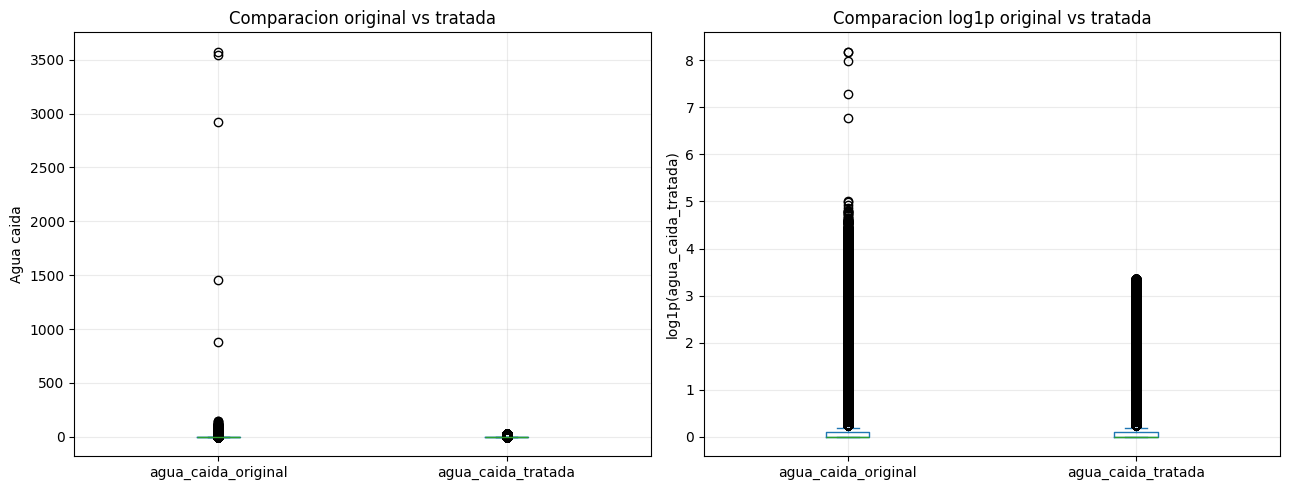

In [62]:
comparacion_lluvia = pd.DataFrame({
    'agua_caida_original': df_eda['agua_caida'],
    'agua_caida_tratada': df_eda['agua_caida_tratada']
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparacion_lluvia.plot(kind='box', ax=axes[0])
axes[0].set_title('Comparacion original vs tratada')
axes[0].set_ylabel('Agua caida')

np.log1p(comparacion_lluvia).plot(kind='box', ax=axes[1])
axes[1].set_title('Comparacion log1p original vs tratada')
axes[1].set_ylabel('log1p(agua_caida_tratada)')

plt.tight_layout()
plt.show()


**Analisis del tratamiento de lluvia:**

El tratamiento reemplaza solo los extremos superiores de `agua_caida`, definidos por percentil 99, usando la mediana de dias con lluvia no extrema. Esta decision reduce la distorsion de promedios y correlaciones, pero conserva la variable original para auditoria y comparacion. No se usa la mediana general porque en lluvia diaria suele ser 0, lo que transformaria eventos de lluvia en dias sin precipitacion.


**Analisis de transformaciones iniciales:**

Las transformaciones realizadas permiten continuar el analisis sin perder trazabilidad. La correccion de texto mejora la interpretacion de regiones y estaciones en graficos, y la macrozona permite resumir regiones en grupos territoriales mas interpretables. Los codigos numericos permiten estudiar correlaciones exploratorias, pero no reemplazan una preparacion formal para modelamiento. Los outliers quedan marcados y, para lluvia extrema, se crea una variable tratada que reduce distorsion sin perder el registro original.


## 2.5 Analisis estadisticos basicos

Se calculan estadisticos descriptivos para comprender rangos, dispersion y comportamiento general de las variables numericas. Desde esta seccion, los resumenes de precipitacion usan `agua_caida_tratada` para evitar que pocos extremos altos dominen las medidas. Luego se agregan resultados por region, macrozona y zona geografica para obtener una lectura territorial en distintos niveles de detalle.


**Mini objetivo:** calcular estadisticos descriptivos de las variables numericas base, comparando lluvia original y lluvia tratada.


In [63]:
variables_numericas_base = ['altura', 'latitud', 'longitud', 'agua_caida', 'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media']
estadisticos_base = df_eda[variables_numericas_base].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

display(estadisticos_base)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
altura,"187,876.000",441.946,741.220,5.000,6.000,11.000,53.000,156.000,474.000,"2,326.000","3,700.000","4,084.000"
latitud,"187,876.000",-35.851,8.857,-62.192,-54.932,-53.130,-40.084,-33.728,-32.222,-19.277,-18.200,-17.595
longitud,"187,876.000",-71.691,4.176,-109.433,-78.833,-73.735,-72.344,-71.187,-70.683,-69.295,-67.616,-58.980
agua_caida,"170,813.000",1.494,15.673,0.000,0.000,0.000,0.000,0.000,0.100,8.600,27.800,"3,574.300"
agua_caida_tratada,"170,813.000",1.011,3.340,0.000,0.000,0.000,0.000,0.000,0.100,7.000,19.000,27.800
temp_max,"166,829.000",18.915,7.305,-29.800,0.800,6.900,14.000,18.700,24.100,31.000,34.000,49.900
temp_min,"165,911.000",7.657,5.505,-49.900,-5.800,-1.300,4.100,7.800,11.400,16.500,19.800,35.600
temp_media,"165,163.000",12.755,5.603,-22.100,-1.600,3.100,9.200,12.800,16.700,21.600,23.800,31.100


**Mini objetivo:** resumir precipitacion y temperatura por region para detectar patrones territoriales.


In [64]:
estadisticos_region = df_eda.groupby('nombre_region').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_region)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
nombre_region,,,,,
De Los Lagos,16434,9,2.875,"40,456.400",10.457
Aysén del Gral. Carlos Ibáñez del Campo,10437,6,2.811,"23,869.000",8.831
De Los Ríos,6569,4,2.499,"13,528.900",11.342
De La Araucanía,10956,6,1.827,"17,293.900",11.399
Del Biobío,8764,5,1.586,"12,551.500",12.912
De Ñuble,4383,3,1.293,"5,422.900",13.047
Magallanes y de la Antártica Chilena,19347,11,1.128,"21,315.800",5.769
Del Maule,5456,3,0.976,"5,060.500",14.223
Del Libertador Gral. Bernardo O'Higgins,9092,5,0.597,"4,900.800",13.775


**Mini objetivo:** resumir precipitacion y temperatura por zona geografica para comparar comportamientos climaticos.


In [65]:
estadisticos_zona = df_eda.groupby('zona_geografica').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_zona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
zona_geografica,,,,,
Litoral,64838,36,1.289,"76,573.600",12.240
Valle,86617,51,1.054,"84,139.100",13.001
Secano Interior,2557,2,0.825,"1,886.200",13.143
PreCordillera,19060,11,0.447,"7,114.000",14.153
Cordillera,7527,5,0.274,"1,730.300",9.473
Secano Costero,7277,4,0.182,"1,284.000",14.021


**Mini objetivo:** resumir precipitacion y temperatura por macrozona para analizar patrones territoriales de mayor escala.


In [66]:
estadisticos_macrozona = df_eda.groupby('macrozona', observed=True).agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).round(3)

display(estadisticos_macrozona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
macrozona,,,,,
Norte Grande,22131,13,0.086,"1,739.400",16.294
Norte Chico,21410,13,0.122,"2,337.800",15.397
Zona Central,80592,47,0.695,"52,186.000",14.015
Zona Sur,33959,19,2.462,"71,279.200",10.919
Zona Austral,29784,17,1.650,"45,184.800",6.696


**Mini objetivo:** graficar precipitacion y temperatura promedio por region para facilitar la comparacion visual.


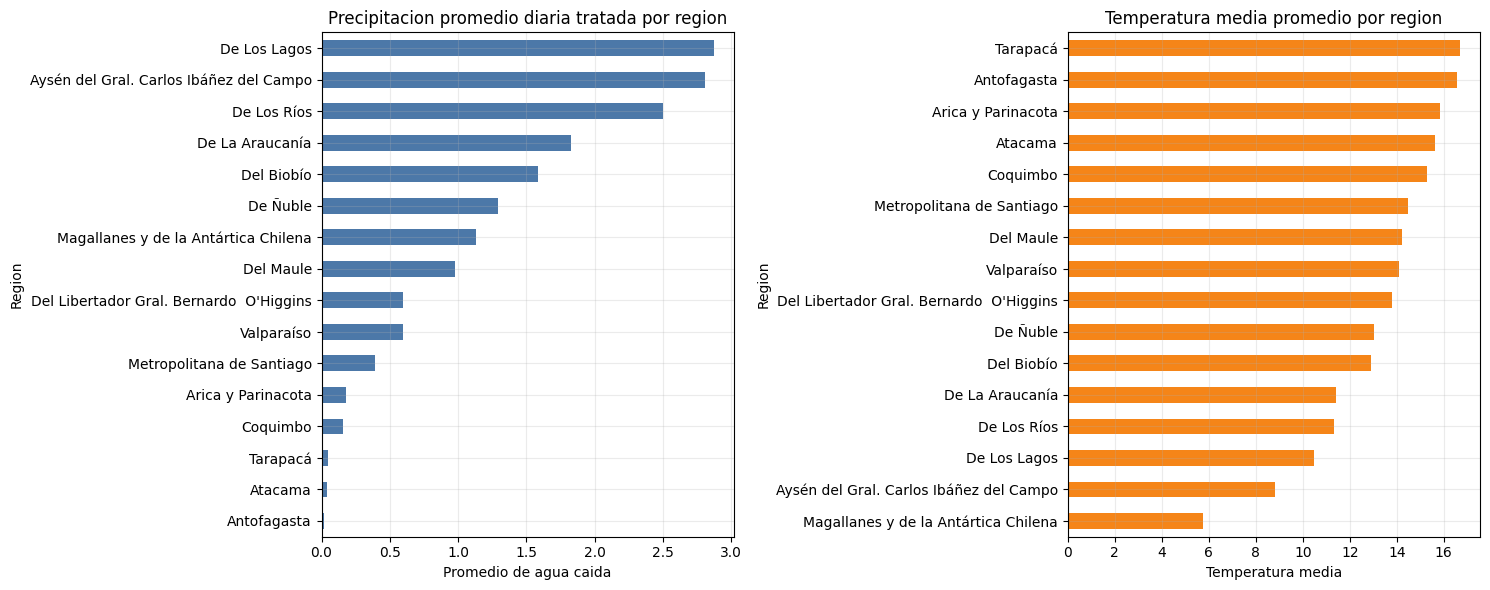

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

estadisticos_region['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por region')
axes[0].set_xlabel('Promedio de agua caida')
axes[0].set_ylabel('Region')

estadisticos_region['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por region')
axes[1].set_xlabel('Temperatura media')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Mini objetivo:** graficar precipitacion y temperatura promedio por zona geografica para facilitar la comparacion visual.


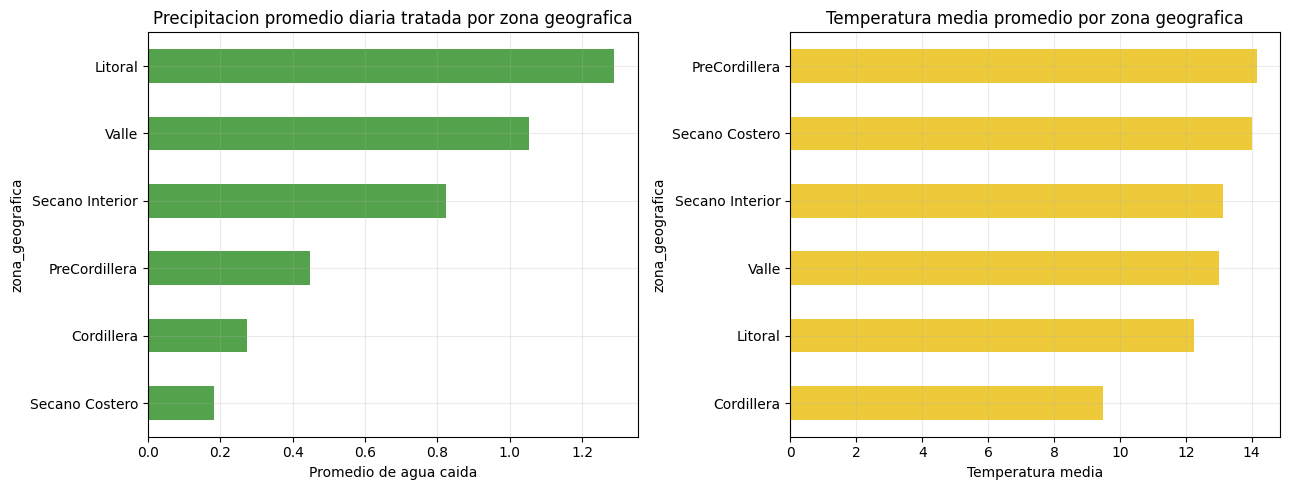

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_zona['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#54a24b')
axes[0].set_title('Precipitacion promedio diaria tratada por zona geografica')
axes[0].set_xlabel('Promedio de agua caida')

estadisticos_zona['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#eeca3b')
axes[1].set_title('Temperatura media promedio por zona geografica')
axes[1].set_xlabel('Temperatura media')

plt.tight_layout()
plt.show()


**Mini objetivo:** graficar precipitacion y temperatura promedio por macrozona para comparar el comportamiento norte-centro-sur de forma agregada.


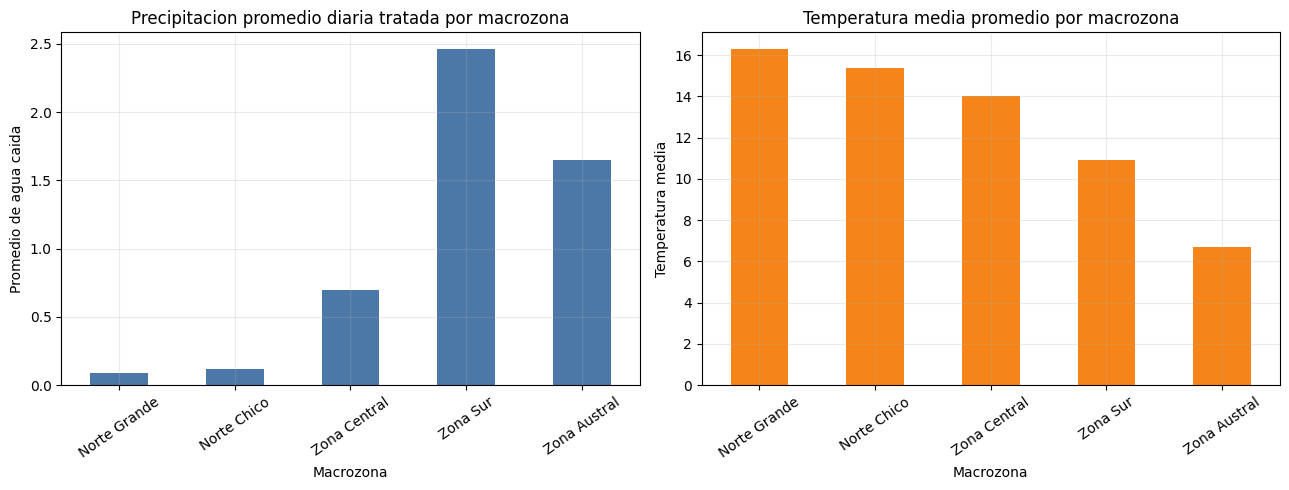

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_macrozona['agua_promedio'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por macrozona')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Promedio de agua caida')
axes[0].tick_params(axis='x', rotation=35)

estadisticos_macrozona['temp_media_promedio'].plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Mini objetivo:** usar boxplots por macrozona para observar dispersion, diferencias territoriales y presencia de valores extremos.


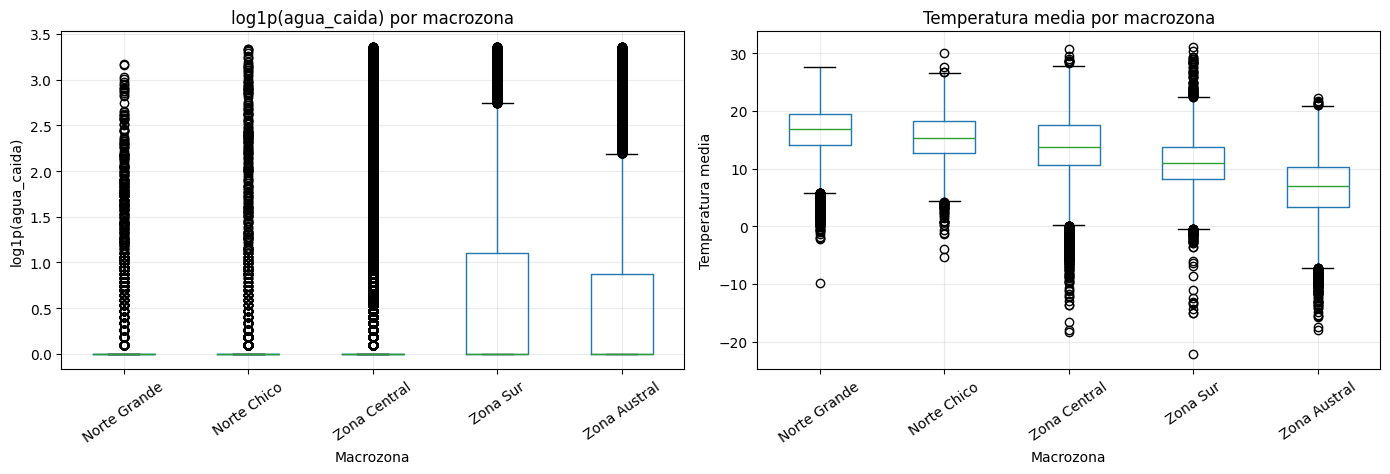

In [70]:
macrozona_box = df_eda[['macrozona', 'agua_caida_tratada', 'temp_media']].copy()
macrozona_box['agua_caida_log'] = np.log1p(macrozona_box['agua_caida_tratada'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

macrozona_box.boxplot(column='agua_caida_log', by='macrozona', ax=axes[0], rot=35)
axes[0].set_title('log1p(agua_caida) por macrozona')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('log1p(agua_caida)')

macrozona_box.boxplot(column='temp_media', by='macrozona', ax=axes[1], rot=35)
axes[1].set_title('Temperatura media por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por macrozona:**

La macrozona permite leer los datos de manera mas clara que una comparacion con muchas regiones. Esta agrupacion ayuda a distinguir patrones climaticos amplios entre norte, centro, sur y extremo austral, manteniendo una interpretacion territorial comprensible para el analisis de negocio.


**Mini objetivo:** observar distribuciones de precipitacion transformada y temperaturas para entender su forma estadistica.


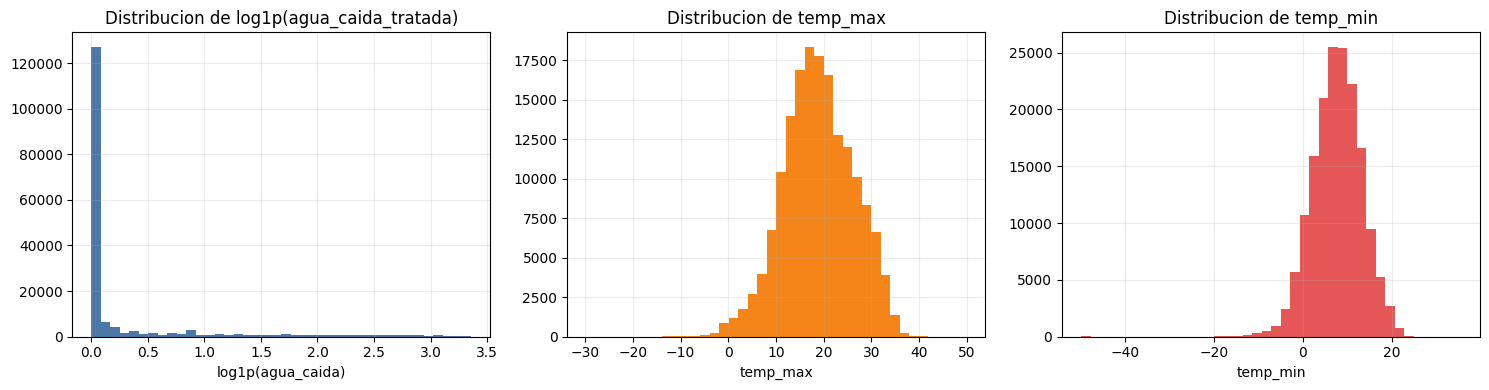

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

np.log1p(df_eda['agua_caida_tratada'].dropna()).hist(bins=40, ax=axes[0], color='#4c78a8')
axes[0].set_title('Distribucion de log1p(agua_caida_tratada)')
axes[0].set_xlabel('log1p(agua_caida)')

for columna, ax, color in zip(['temp_max', 'temp_min'], axes[1:], ['#f58518', '#e45756']):
    df_eda[columna].dropna().hist(bins=40, ax=ax, color=color)
    ax.set_title(f'Distribucion de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis estadistico:**

Los estadisticos y graficos muestran que la precipitacion, incluso tratada, no se distribuye de forma normal: predominan valores bajos y pocos eventos concentran montos altos. Las temperaturas presentan una distribucion mas continua y son mas adecuadas para analisis de correlacion directa. Las comparaciones por region, macrozona y zona permiten comenzar a validar hipotesis territoriales en distintos niveles de detalle.


## 2.6 Matriz de Correlacion

La matriz de correlacion permite analizar relaciones lineales entre variables numericas. No implica causalidad, pero ayuda a identificar variables que podrian aportar informacion en modelos predictivos.


**Mini objetivo:** calcular la matriz de correlacion inicial y graficarla con etiquetas numericas para facilitar su interpretacion.


,altura,latitud,longitud,mes,agua_caida_tratada,temp_max,temp_min,temp_media
altura,1.000,0.393,0.182,-0.002,-0.092,0.074,-0.161,-0.031
latitud,0.393,1.000,-0.062,-0.002,-0.168,0.518,0.487,0.559
longitud,0.182,-0.062,1.000,-0.001,-0.084,-0.095,-0.234,-0.184
mes,-0.002,-0.002,-0.001,1.000,0.007,-0.136,-0.150,-0.157
agua_caida_tratada,-0.092,-0.168,-0.084,0.007,1.000,-0.240,-0.048,-0.167
temp_max,0.074,0.518,-0.095,-0.136,-0.240,1.000,0.582,0.901
temp_min,-0.161,0.487,-0.234,-0.150,-0.048,0.582,1.000,0.859
temp_media,-0.031,0.559,-0.184,-0.157,-0.167,0.901,0.859,1.000


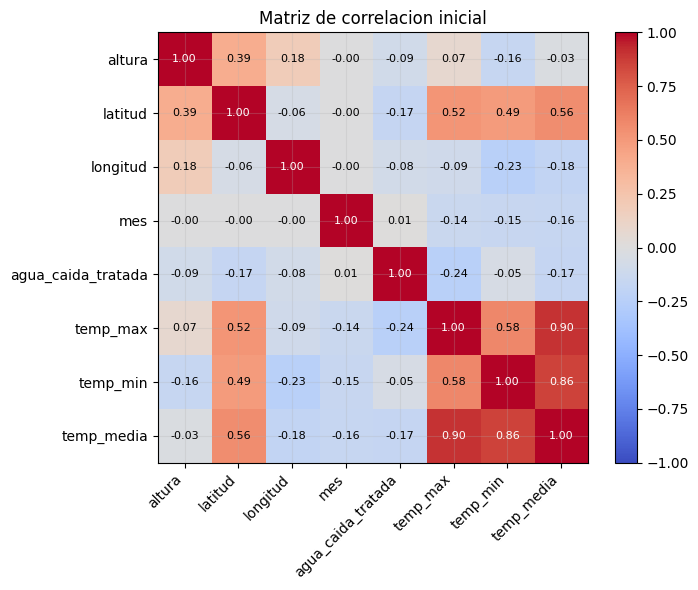

In [72]:
def graficar_matriz_correlacion(correlacion, titulo, figsize=(8, 6), rotacion=45):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)

    ax.set_xticks(range(len(correlacion.columns)))
    ax.set_yticks(range(len(correlacion.index)))
    ax.set_xticklabels(correlacion.columns, rotation=rotacion, ha='right')
    ax.set_yticklabels(correlacion.index)
    ax.set_title(titulo)

    for fila in range(len(correlacion.index)):
        for columna in range(len(correlacion.columns)):
            valor = correlacion.iloc[fila, columna]
            color_texto = 'white' if abs(valor) >= 0.60 else 'black'
            ax.text(columna, fila, f'{valor:.2f}', ha='center', va='center', fontsize=8, color=color_texto)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

columnas_correlacion_inicial = [
    'altura', 'latitud', 'longitud', 'mes', 'agua_caida_tratada',
    'temp_max', 'temp_min', 'temp_media'
]

corr_inicial = df_eda[columnas_correlacion_inicial].corr(numeric_only=True)

display(corr_inicial.round(3))
graficar_matriz_correlacion(corr_inicial, 'Matriz de correlacion inicial', figsize=(8, 6), rotacion=45)


**Analisis de correlacion inicial:**

Se espera observar una relacion fuerte entre las variables de temperatura, especialmente entre `temp_media`, `temp_max` y `temp_min`. Las variables geograficas como `latitud` y `altura` pueden mostrar relacion con temperatura, lo que es consistente con el comportamiento climatico esperado. La variable `agua_caida_tratada` puede presentar correlaciones mas debiles porque la lluvia diaria suele depender de patrones no lineales y eventos puntuales.


## 2.7 Patrones/comportamientos detectados

En esta seccion se revisan patrones temporales, geograficos y climaticos mediante graficos. Cada grafico responde a una pregunta concreta: como cambia la lluvia por mes, como cambia la temperatura, que zonas concentran mas precipitacion y como se relacionan ubicacion y clima.


**Mini objetivo:** construir una serie mensual para observar evolucion temporal de precipitacion y temperatura.


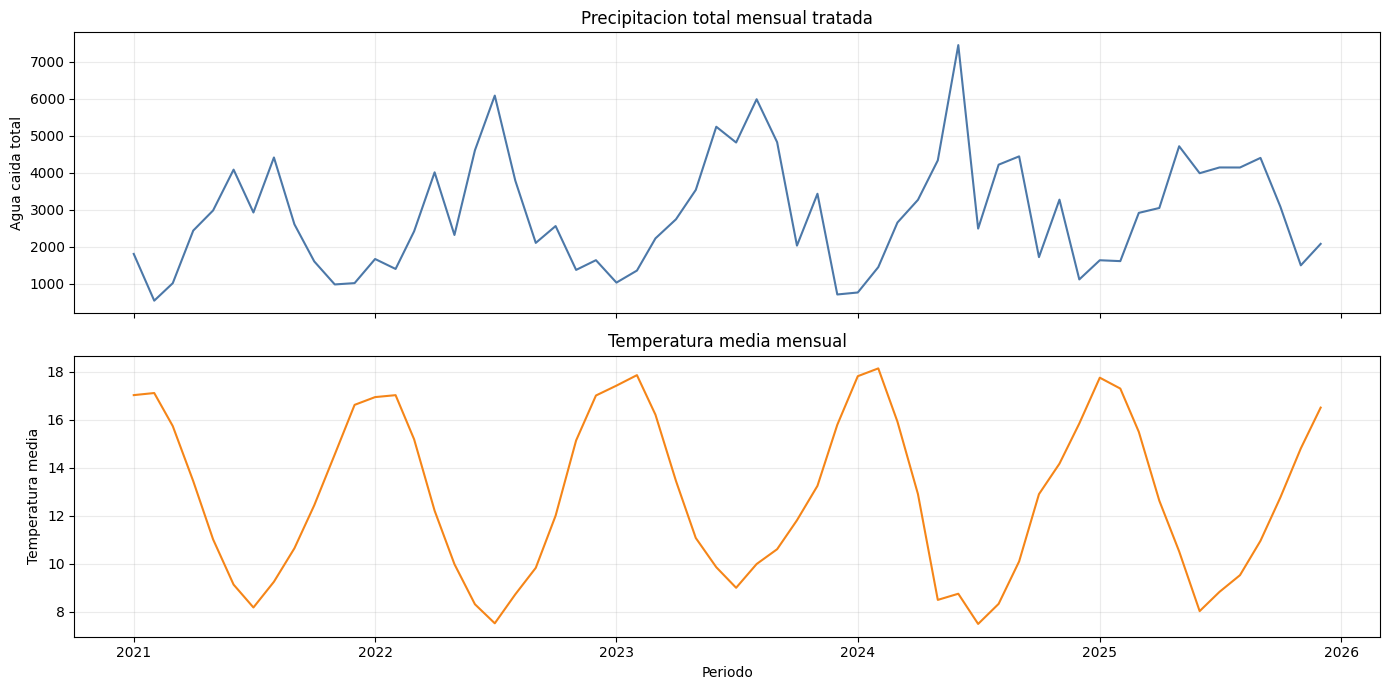

In [73]:
mensual = df_eda.assign(periodo=df_eda['fecha'].dt.to_period('M').dt.to_timestamp()) \
    .groupby('periodo').agg(
        agua_total=('agua_caida_tratada', 'sum'),
        agua_promedio=('agua_caida_tratada', 'mean'),
        temp_media=('temp_media', 'mean')
    ).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(mensual['periodo'], mensual['agua_total'], color='#4c78a8')
axes[0].set_title('Precipitacion total mensual tratada')
axes[0].set_ylabel('Agua caida total')

axes[1].plot(mensual['periodo'], mensual['temp_media'], color='#f58518')
axes[1].set_title('Temperatura media mensual')
axes[1].set_ylabel('Temperatura media')
axes[1].set_xlabel('Periodo')

plt.tight_layout()
plt.show()


**Mini objetivo:** agrupar por mes para analizar estacionalidad anual en lluvia y temperatura.


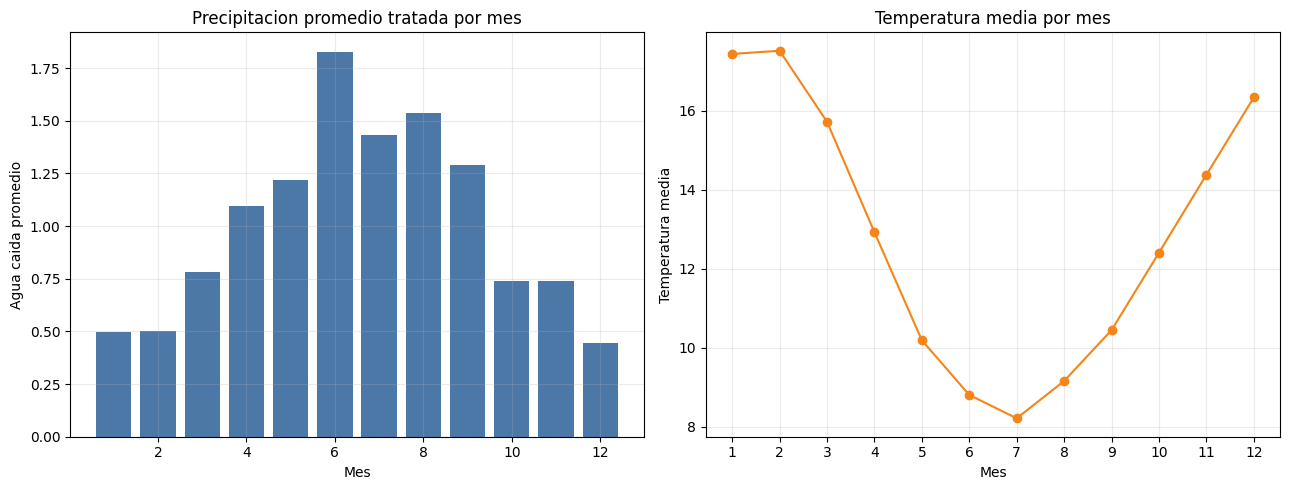

In [74]:
por_mes = df_eda.groupby('mes').agg(
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media=('temp_media', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(por_mes['mes'], por_mes['agua_promedio'], color='#4c78a8')
axes[0].set_title('Precipitacion promedio tratada por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Agua caida promedio')

axes[1].plot(por_mes['mes'], por_mes['temp_media'], marker='o', color='#f58518')
axes[1].set_title('Temperatura media por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura media')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


**Mini objetivo:** comparar precipitacion tratada por zona geografica usando valores originales de escala y una transformacion logaritmica temporal.


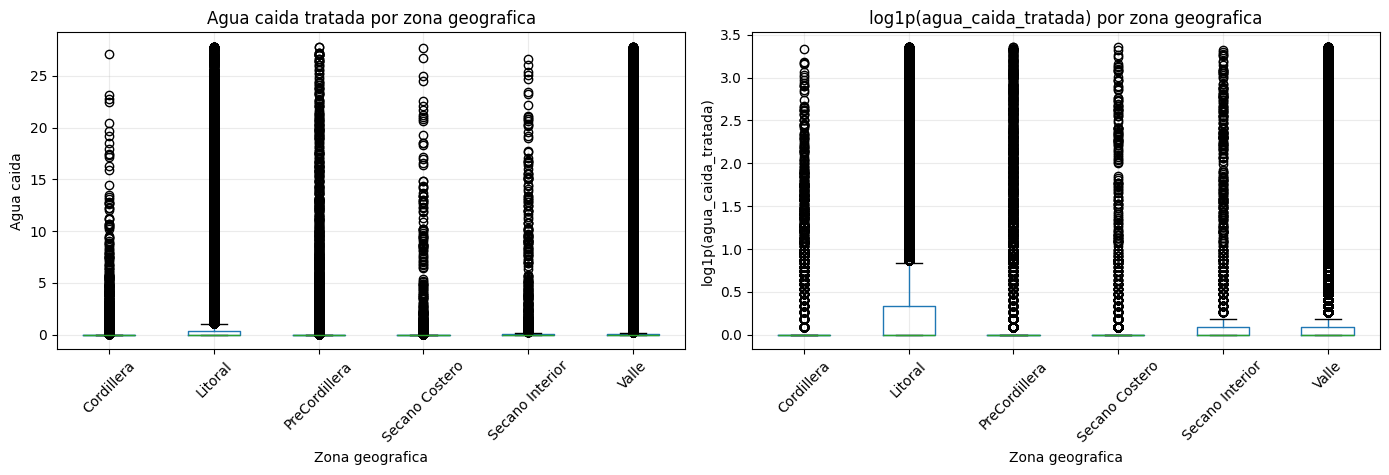

In [75]:
agua_caida_log_zona = pd.DataFrame({
    'zona_geografica': df_eda['zona_geografica'],
    'agua_caida_log': np.log1p(df_eda['agua_caida_tratada'])
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_eda.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[0], rot=45)
axes[0].set_title('Agua caida tratada por zona geografica')
axes[0].set_xlabel('Zona geografica')
axes[0].set_ylabel('Agua caida')

agua_caida_log_zona.boxplot(column='agua_caida_log', by='zona_geografica', ax=axes[1], rot=45)
axes[1].set_title('log1p(agua_caida_tratada) por zona geografica')
axes[1].set_xlabel('Zona geografica')
axes[1].set_ylabel('log1p(agua_caida_tratada)')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Mini objetivo:** usar una muestra para visualizar relaciones entre ubicacion geografica y temperatura sin saturar el grafico.


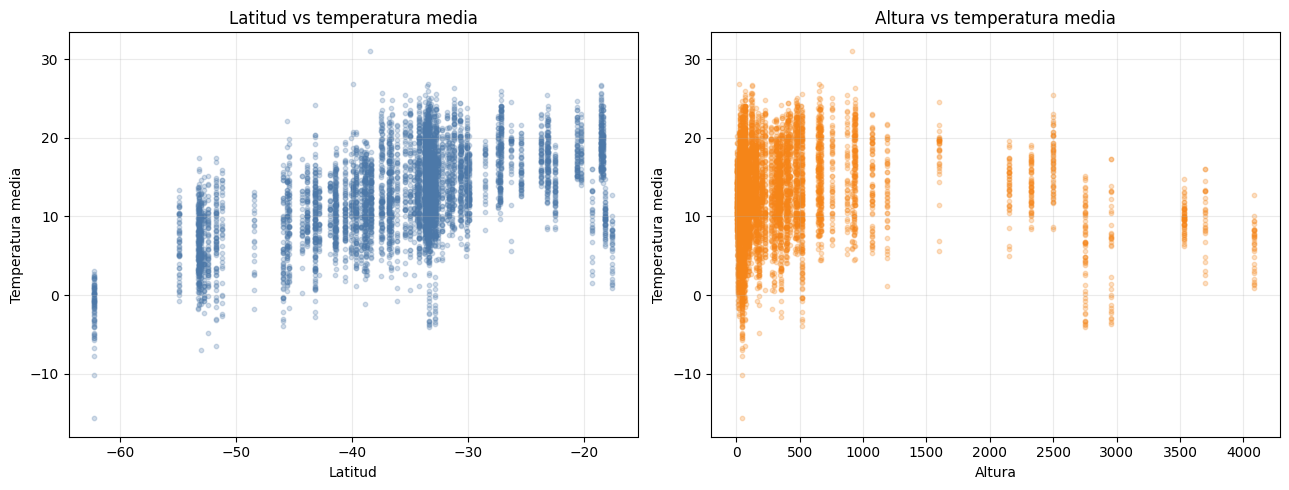

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

muestra_scatter = df_eda[['latitud', 'altura', 'temp_media', 'agua_caida_tratada']].dropna().sample(
    n=min(6000, df_eda[['latitud', 'altura', 'temp_media', 'agua_caida_tratada']].dropna().shape[0]),
    random_state=42
)

axes[0].scatter(muestra_scatter['latitud'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#4c78a8')
axes[0].set_title('Latitud vs temperatura media')
axes[0].set_xlabel('Latitud')
axes[0].set_ylabel('Temperatura media')

axes[1].scatter(muestra_scatter['altura'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#f58518')
axes[1].set_title('Altura vs temperatura media')
axes[1].set_xlabel('Altura')
axes[1].set_ylabel('Temperatura media')

plt.tight_layout()
plt.show()


**Mini objetivo:** agregar datos por estacion para visualizar distribucion geografica y precipitacion acumulada.


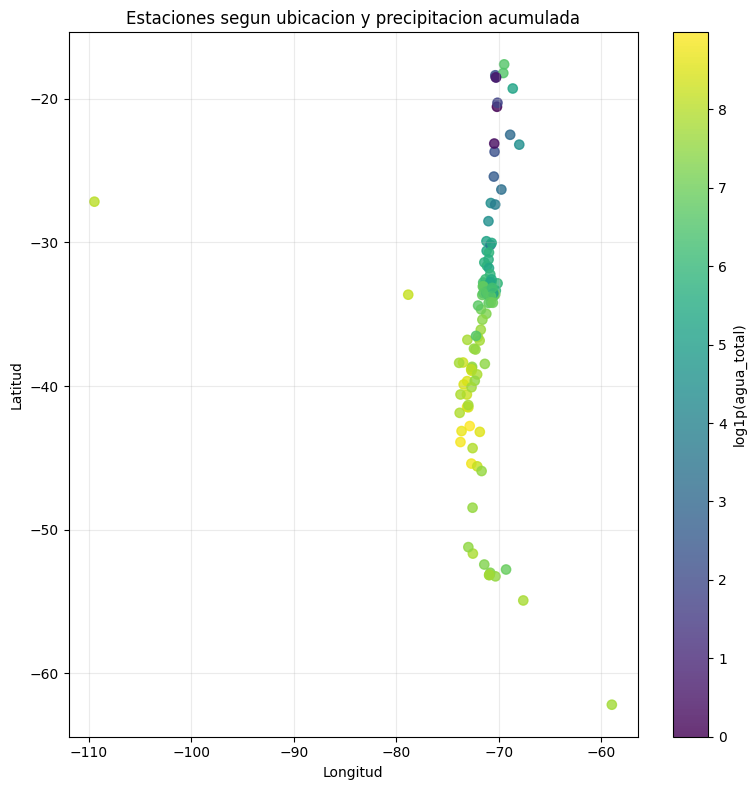

In [77]:
estaciones_geo = df_eda.groupby(['codigo_estacion', 'nombre_estacion']).agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media=('temp_media', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    estaciones_geo['longitud'], estaciones_geo['latitud'],
    c=np.log1p(estaciones_geo['agua_total']), s=45, cmap='viridis', alpha=0.8
)
ax.set_title('Estaciones segun ubicacion y precipitacion acumulada')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.colorbar(scatter, ax=ax, label='log1p(agua_total)')
plt.tight_layout()
plt.show()


**Patrones detectados inicialmente:**

Los graficos temporales permiten observar estacionalidad: las precipitaciones y temperaturas cambian segun el mes. Los boxplots por zona muestran diferencias territoriales y tambien confirman la presencia de eventos extremos en precipitacion. Los graficos de latitud y altura ayudan a evaluar la hipotesis de que la ubicacion geografica influye en la temperatura. El grafico geografico de estaciones permite visualizar si la lluvia acumulada se concentra en ciertas areas del pais.


## 2.8 Nuevas variables a partir de analisis

A partir del entendimiento inicial se crean variables que facilitan el analisis y el futuro modelamiento. Estas variables traducen informacion climatica y temporal a formatos mas utiles para regresion, clasificacion y clustering.

| Nueva variable | Descripcion | Uso esperado |
|---|---|---|
| `llueve` | 1 si `agua_caida_tratada > 0`, 0 si no | Clasificacion binaria |
| `lluvia_intensa` | 1 si `agua_caida_tratada` supera el percentil 95 | Deteccion/clasificacion de lluvia alta no extrema |
| `rango_termico` | `temp_max - temp_min` | Analisis de variabilidad termica |
| `estacion_anio` | Verano, otono, invierno, primavera | Analisis estacional |
| `mes_sin`, `mes_cos` | Representacion ciclica del mes | Modelos con comportamiento anual |
| `agua_caida_log` | `log1p(agua_caida_tratada)` | Analisis de variable asimetrica tratada |


**Mini objetivo:** crear variables derivadas para clasificacion, estacionalidad, rango termico y analisis de lluvia extrema.


In [78]:
umbral_lluvia_intensa = df_eda['agua_caida_tratada'].quantile(0.95)

def obtener_estacion_anio(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    if mes in [3, 4, 5]:
        return 'Otono'
    if mes in [6, 7, 8]:
        return 'Invierno'
    return 'Primavera'

df_eda['llueve'] = np.where(df_eda['agua_caida_tratada'].isna(), np.nan, (df_eda['agua_caida_tratada'] > 0).astype(int))
df_eda['lluvia_intensa'] = np.where(df_eda['agua_caida_tratada'].isna(), np.nan, (df_eda['agua_caida_tratada'] >= umbral_lluvia_intensa).astype(int))
df_eda['rango_termico'] = df_eda['temp_max'] - df_eda['temp_min']
df_eda['estacion_anio'] = df_eda['mes'].apply(obtener_estacion_anio)
df_eda['mes_sin'] = np.sin(2 * np.pi * df_eda['mes'] / 12)
df_eda['mes_cos'] = np.cos(2 * np.pi * df_eda['mes'] / 12)
df_eda['agua_caida_log'] = np.log1p(df_eda['agua_caida_tratada'])

resumen_nuevas_variables = pd.DataFrame([
    {'variable': 'umbral_lluvia_intensa', 'valor': umbral_lluvia_intensa},
    {'variable': 'dias_con_lluvia', 'valor': df_eda['llueve'].sum()},
    {'variable': 'eventos_lluvia_intensa', 'valor': df_eda['lluvia_intensa'].sum()},
    {'variable': 'rango_termico_promedio', 'valor': df_eda['rango_termico'].mean()},
])

display(resumen_nuevas_variables)
display(df_eda[['fecha', 'agua_caida', 'agua_caida_tratada', 'llueve', 'lluvia_intensa', 'rango_termico', 'estacion_anio', 'mes_sin', 'mes_cos']].head())


,variable,valor
0,umbral_lluvia_intensa,7.000
1,dias_con_lluvia,"43,657.000"
2,eventos_lluvia_intensa,"8,610.000"
3,rango_termico_promedio,11.284


,fecha,agua_caida,agua_caida_tratada,llueve,lluvia_intensa,rango_termico,estacion_anio,mes_sin,mes_cos
0,2023-01-01,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
1,2023-01-02,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
2,2023-01-03,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
3,2023-01-04,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
4,2023-01-05,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866


**Analisis de nuevas variables:**

Las variables creadas usan la precipitacion tratada y conectan directamente con las hipotesis del proyecto. `llueve` y `lluvia_intensa` permiten pasar desde regresion a clasificacion. `rango_termico` resume diferencias entre maxima y minima diaria. `estacion_anio`, `mes_sin` y `mes_cos` permiten representar estacionalidad, que es esperable en datos meteorologicos.


## 2.9 Matriz de Correlacion

Luego de crear nuevas variables, se calcula una segunda matriz de correlacion. El objetivo es revisar si las variables derivadas entregan senales adicionales para explicar precipitacion, temperatura o eventos de lluvia.


**Mini objetivo:** calcular una segunda correlacion incluyendo variables derivadas y graficarla con etiquetas numericas.


,altura,latitud,longitud,mes,mes_sin,mes_cos,agua_caida_tratada,agua_caida_log,temp_max,temp_min,temp_media,rango_termico,llueve,lluvia_intensa,region_cod,zona_geografica_cod,macrozona_cod
altura,1.000,0.393,0.182,-0.002,0.002,-0.001,-0.092,-0.122,0.074,-0.161,-0.031,0.238,-0.154,-0.074,-0.089,-0.184,-0.374
latitud,0.393,1.000,-0.062,-0.002,0.001,-0.001,-0.168,-0.254,0.518,0.487,0.559,0.182,-0.343,-0.121,-0.216,-0.073,-0.947
longitud,0.182,-0.062,1.000,-0.001,0.001,-0.001,-0.084,-0.113,-0.095,-0.234,-0.184,0.098,-0.131,-0.065,-0.092,0.031,-0.080
mes,-0.002,-0.002,-0.001,1.000,-0.762,0.205,0.007,0.011,-0.136,-0.150,-0.157,-0.028,0.009,0.007,0.001,0.000,0.001
mes_sin,0.002,0.001,0.001,-0.762,1.000,-0.001,-0.045,-0.056,0.281,0.279,0.316,0.085,-0.062,-0.040,-0.001,-0.002,-0.000
mes_cos,-0.001,-0.001,-0.001,0.205,-0.001,1.000,-0.116,-0.136,0.443,0.369,0.479,0.196,-0.173,-0.095,0.001,-0.001,0.001
agua_caida_tratada,-0.092,-0.168,-0.084,0.007,-0.045,-0.116,1.000,0.915,-0.240,-0.048,-0.167,-0.244,0.517,0.879,-0.049,-0.003,0.196
agua_caida_log,-0.122,-0.254,-0.113,0.011,-0.056,-0.136,0.915,1.000,-0.328,-0.088,-0.241,-0.314,0.718,0.796,-0.046,-0.020,0.283
temp_max,0.074,0.518,-0.095,-0.136,0.281,0.443,-0.240,-0.328,1.000,0.582,0.901,0.675,-0.411,-0.184,-0.021,0.252,-0.473
temp_min,-0.161,0.487,-0.234,-0.150,0.279,0.369,-0.048,-0.088,0.582,1.000,0.859,-0.207,-0.172,-0.030,-0.128,-0.126,-0.456


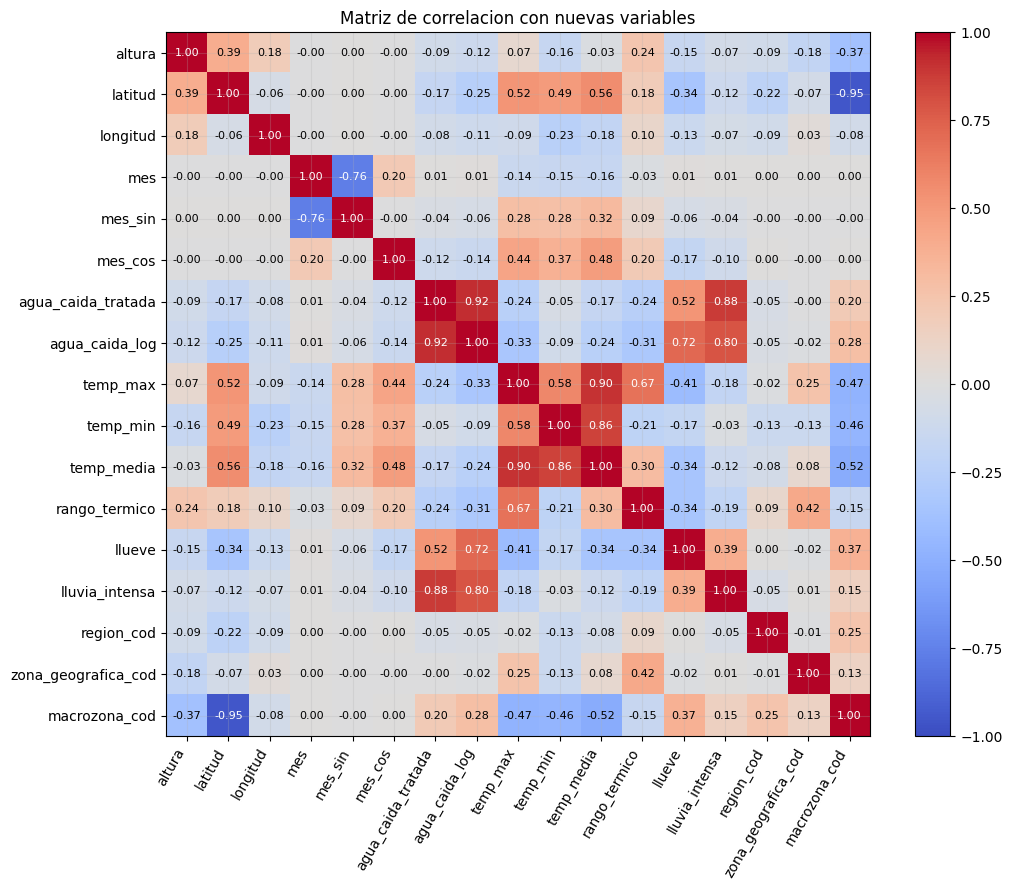

In [79]:
columnas_correlacion_nuevas = [
    'altura', 'latitud', 'longitud', 'mes', 'mes_sin', 'mes_cos',
    'agua_caida_tratada', 'agua_caida_log', 'temp_max', 'temp_min', 'temp_media',
    'rango_termico', 'llueve', 'lluvia_intensa', 'region_cod',
    'zona_geografica_cod', 'macrozona_cod'
]

corr_nuevas = df_eda[columnas_correlacion_nuevas].corr(numeric_only=True)

display(corr_nuevas.round(3))
graficar_matriz_correlacion(corr_nuevas, 'Matriz de correlacion con nuevas variables', figsize=(12, 9), rotacion=60)


**Analisis de correlacion con nuevas variables:**

La segunda matriz permite comparar variables originales y derivadas. `agua_caida_log` puede mostrar relaciones mas interpretables que la lluvia cruda, porque se calcula sobre `agua_caida_tratada`, debido a la asimetria de la precipitacion. La inclusion de `macrozona_cod` permite revisar si la agrupacion territorial aporta alguna senal exploratoria. Las variables `llueve` y `lluvia_intensa` seran utiles para modelos de clasificacion, aunque no necesariamente tendran correlaciones lineales fuertes con todas las variables climaticas.


## 2.10 Patrones/comportamientos detectados con nuevas variables

Con las nuevas variables se analizan patrones mas cercanos al futuro modelamiento: dias con lluvia, lluvia intensa, estacionalidad y relaciones entre variables climaticas. Tambien se incluye una visualizacion tipo pairplot para observar relaciones combinadas entre variables.


**Mini objetivo:** contar registros con y sin lluvia para revisar el balance de la variable objetivo de clasificacion.


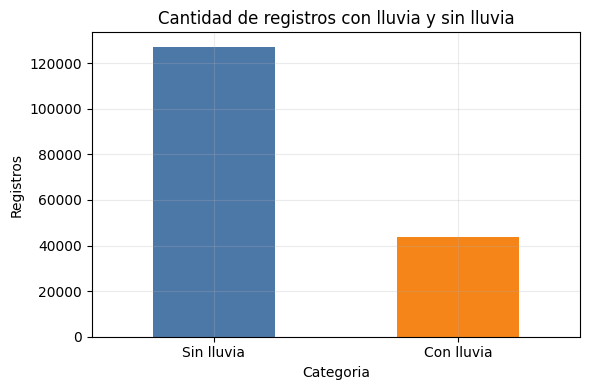

In [80]:
conteo_lluvia = df_eda['llueve'].map({0: 'Sin lluvia', 1: 'Con lluvia'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
conteo_lluvia.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('Cantidad de registros con lluvia y sin lluvia')
ax.set_xlabel('Categoria')
ax.set_ylabel('Registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Mini objetivo:** comparar eventos de lluvia intensa por region, zona geografica y macrozona.


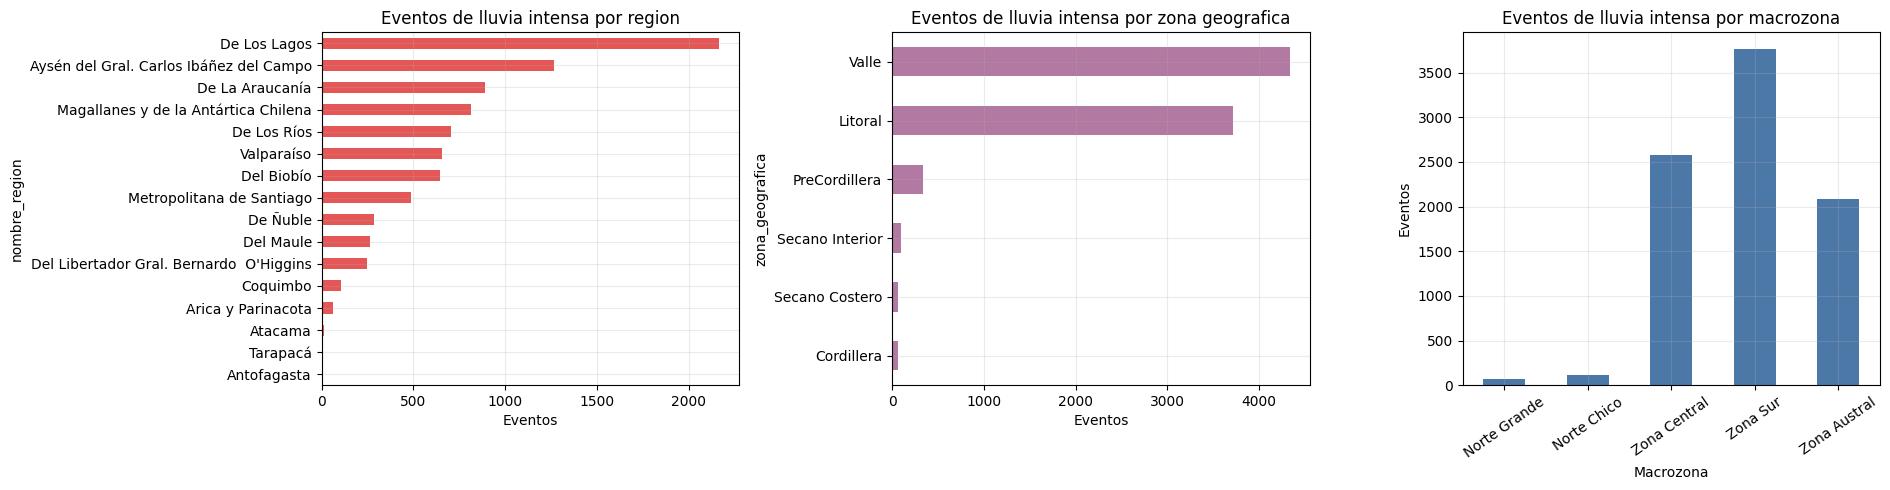

In [81]:
lluvia_intensa_region = df_eda[df_eda['lluvia_intensa'] == 1].groupby('nombre_region').size().sort_values()
lluvia_intensa_zona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('zona_geografica').size().sort_values()
lluvia_intensa_macrozona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('macrozona', observed=True).size()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

lluvia_intensa_region.plot(kind='barh', ax=axes[0], color='#e45756')
axes[0].set_title('Eventos de lluvia intensa por region')
axes[0].set_xlabel('Eventos')

lluvia_intensa_zona.plot(kind='barh', ax=axes[1], color='#b279a2')
axes[1].set_title('Eventos de lluvia intensa por zona geografica')
axes[1].set_xlabel('Eventos')

lluvia_intensa_macrozona.plot(kind='bar', ax=axes[2], color='#4c78a8')
axes[2].set_title('Eventos de lluvia intensa por macrozona')
axes[2].set_xlabel('Macrozona')
axes[2].set_ylabel('Eventos')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Mini objetivo:** comparar temperatura y precipitacion transformada segun lluvia y estacion del anio.


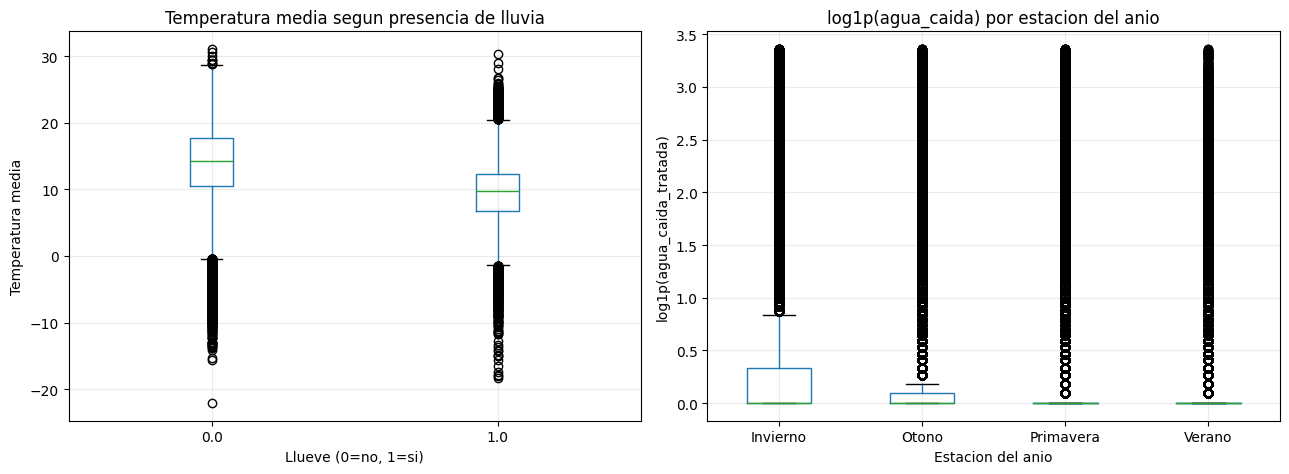

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_eda.boxplot(column='temp_media', by='llueve', ax=axes[0])
axes[0].set_title('Temperatura media segun presencia de lluvia')
axes[0].set_xlabel('Llueve (0=no, 1=si)')
axes[0].set_ylabel('Temperatura media')

df_eda.boxplot(column='agua_caida_log', by='estacion_anio', ax=axes[1])
axes[1].set_title('log1p(agua_caida) por estacion del anio')
axes[1].set_xlabel('Estacion del anio')
axes[1].set_ylabel('log1p(agua_caida_tratada)')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Mini objetivo:** construir una visualizacion tipo pairplot para observar relaciones cruzadas entre variables climaticas y geograficas.


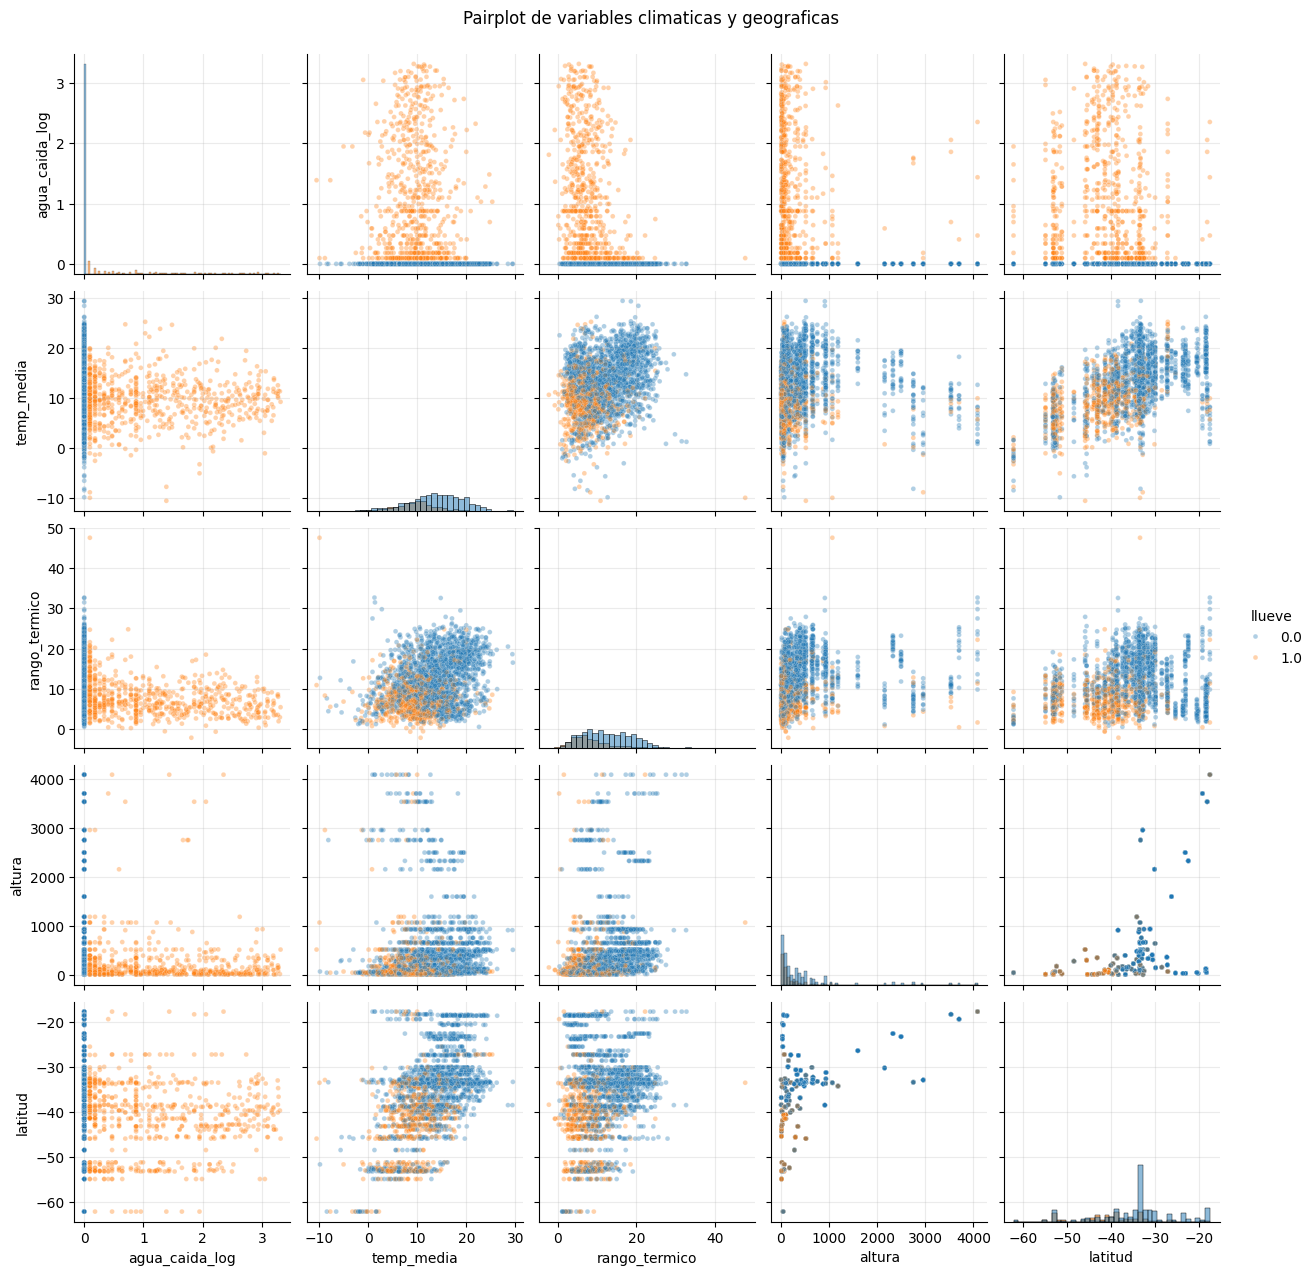

In [83]:
variables_pairplot = ['agua_caida_log', 'temp_media', 'rango_termico', 'altura', 'latitud', 'llueve']
muestra_pairplot = df_eda[variables_pairplot].dropna().sample(
    n=min(2500, df_eda[variables_pairplot].dropna().shape[0]), random_state=42
)

if sns is not None:
    sns.pairplot(
        muestra_pairplot,
        vars=['agua_caida_log', 'temp_media', 'rango_termico', 'altura', 'latitud'],
        hue='llueve',
        diag_kind='hist',
        plot_kws={'alpha': 0.35, 's': 12}
    )
    plt.suptitle('Pairplot de variables climaticas y geograficas', y=1.02)
    plt.show()
else:
    colores = np.where(muestra_pairplot['llueve'] == 1, '#f58518', '#4c78a8')
    scatter_matrix(
        muestra_pairplot[['agua_caida_log', 'temp_media', 'rango_termico', 'altura', 'latitud']],
        figsize=(12, 12), diagonal='hist', color=colores, alpha=0.35
    )
    plt.suptitle('Scatter matrix tipo pairplot de variables climaticas y geograficas', y=0.92)
    plt.show()


**Analisis de patrones con nuevas variables:**

Las variables derivadas permiten observar el problema desde una perspectiva mas util para mineria de datos. La variable `llueve` separa el dataset en dos clases, mientras que `lluvia_intensa` permite estudiar eventos poco frecuentes. Los boxplots comparan condiciones termicas y estacionales. La visualizacion tipo pairplot ayuda a detectar relaciones no evidentes entre lluvia, temperatura, rango termico, altura y latitud.


## Cierre de Fase 2

En esta fase se corrigio la carga del dataset, se identificaron tipos de variables, nulos, outliers, transformaciones iniciales, estadisticos basicos, correlaciones y patrones. Tambien se crearon nuevas variables que conectan el analisis exploratorio con las siguientes fases del proyecto.

Decisiones principales para continuar:

1. Usar `dataset_precipitaciones_temperaturas_chile.csv` como fuente principal.
2. Mantener outliers climaticos marcados, conservando el dato original.
3. Usar `agua_caida_tratada` para analisis y modelamiento cuando los extremos altos distorsionen los resultados.
4. Usar `llueve` y `lluvia_intensa` para modelos de clasificacion.
5. Usar `agua_caida_tratada`, `agua_caida_log` o `temp_media` como posibles objetivos de regresion.
6. Usar variables agregadas por estacion para clustering en fases posteriores.

La siguiente fase corresponde a **Transformacion**, donde se prepararan los datos para modelamiento mediante imputacion, encoding y escalamiento.


# 3. Transformacion

Pendiente de desarrollo.

## 3.1 Escalamiento

# 4. Modelamientamiento

Pendiente de desarrollo.

## 4.1 Modelos de regresion
### 4.1.1 Seleccion de variables (X/Y)
### 4.1.2 Seleccion de parametros
### 4.1.3 Aplicacion de modelos
### 4.1.4 Obtencion de metricas

## 4.2 Modelos de clasificacion
### 4.2.1 Seleccion de variables (X/Y)
### 4.2.2 Seleccion de parametros
### 4.2.3 Aplicacion de modelos
### 4.2.4 Obtencion de metricas

## 4.3 Modelos de Cluster
### 4.3.1 Seleccion de variables (X)
### 4.3.2 Seleccion de parametros
### 4.3.3 Aplicacion de modelos
### 4.3.4 Obtencion de metricas

# 5. Evaluacion

Pendiente de desarrollo.

## 5.1 Metricas

Se consideraran metricas como matriz de confusion, R2, RMSE, MAE, F1-score y Silhouette score, segun corresponda al tipo de modelo.

## 5.2 Mejoras del proceso o modelamiento

# 6. Deploy

Pendiente de desarrollo.

El despliegue se planteara como una salida academica reproducible: notebook final, dataset limpio, funciones de prediccion y recomendaciones para uso futuro.